<font color=#009afa size=50>DAT5001 - Visualisation of Data</font>

<font size=50>2 - Creating Graphs and Charts for Presentation</font>

|**Assessment Code:** |PRES1|
|---|---|
|**Author:**|Tom Rowan, ST20285213|
|**Course:**| DAT5001_S2_25|
|**Course Tutor:**|Dr. Imtiaz Khan|


## Initialise Notebook

In [1]:
# Install Requirements Using Pip
# %pip install -r requirements.txt

%pip install requests pandas numpy matplotlib seaborn plotly cartopy geopandas geopy pycountry scikit-learn lifelines networkX holoviews IPython
 

Note: you may need to restart the kernel to use updated packages.


### Import Python Libraries

In [2]:
# Standard Libraries
import json
import random
from datetime import datetime
import sys

# Pandas and numpy
import pandas as pd
import numpy as np

# Matplot Lib
import matplotlib.pyplot as plt
from matplotlib import colormaps
import matplotlib.colors as mcolors
from matplotlib.pyplot import figure
import matplotlib.ticker as mticker
import matplotlib.animation as animation
%matplotlib inline

# Seaborn Graphs
import seaborn as sns

# Cartopy Maps
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Geopandas
import geopandas as gpd

# GeoPy
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

# Pycountry 
import pycountry

# Tabulate
from tabulate import tabulate

# Colorama
from colorama import Fore, Back, Style

# Requests
import requests

# Plotly
import plotly.express as px
import plotly.graph_objects as go

# IPython Display 
from IPython.display import HTML

# Do not print warnings!
import warnings
warnings.filterwarnings('ignore')

### Check for Internet Access

In [3]:
# Function to print coloured output
def print_output (str1, str2, delim=':', colour='yellow'):
    if colour.upper() in dir(Fore):
        colour = colour.upper()
    else:
        colour = 'YELLOW'
    print (f'{getattr(Fore, colour)}{str(str1)}{delim}{Style.RESET_ALL} {str(str2)}')

In [4]:
online = False

# Check for Internet Connectivity
def check_internet (url_list):
    online = False
    for _url in url_list:
        try:
            response = requests.get(_url, timeout=3)
            if response.status_code == 200:
                online = True
                break
        except requests.RequestException:
            output_string = f"Check Internet failed for {_url}"
            print_output ('[FAIL]',output_string, colour='red', delim='')
    return online


_urls_to_check = ['http://connectivitycheck.gstatic.com/generate_204',
                  'https://www.planet4589.org',
                  'https://datascience.daemonchild.com']

if check_internet (_urls_to_check ):
    print_output ('[INTERNET]','Internet Connectivity Detected. Using Internet resources.',colour='green', delim='')
    online = True

else:
    print ()
    print_output ('[INTERNET]','No Internet Connectivity.', colour='red', delim='')
    #sys.exit('Stopping notebook running here.')


[INTERNET] Internet Connectivity Detected. Using Internet resources.


### Load latest version of Cleaned Dataset

In [5]:
if online:
    sdf = pd.read_csv('https://datascience.daemonchild.com/year2/dat5001/pres1/datasets/space_objects_latest.csv')
else:
    sdf = pd.read_csv('../../datasets/space_objects_latest.csv')

In [6]:
# Ensure Launch Date is in datetime format
sdf['Launch Date'] = pd.to_datetime(sdf['Launch Date'], errors='coerce')

# Get the latest launch date
latest_launch = sdf['Launch Date'].max()
print (latest_launch)

2025-12-09 00:00:00


In [7]:
sdf.shape

(66693, 52)

In [8]:
sdf.columns

Index(['Apogee', 'Class', 'CosparID', 'Country', 'Country Code', 'Decay Date',
       'Decay Decade', 'Decay Month', 'Decay Month No', 'Decay Year',
       'Diameter', 'In Orbit', 'Launch Date', 'Launch Decade', 'Launch Month',
       'Launch Month No', 'Launch Year', 'Length', 'Lifespan Days',
       'Lifespan Months', 'Lifespan Years', 'Manufacturer City',
       'Manufacturer Code', 'Manufacturer Country',
       'Manufacturer Country Code', 'Manufacturer Latitude',
       'Manufacturer Long Name', 'Manufacturer Longitude',
       'Manufacturer Parent', 'Manufacturer Short Name', 'Manufacturer State',
       'Mass', 'Name', 'Operator City', 'Operator Code', 'Operator Country',
       'Operator Country Code', 'Operator Latitude', 'Operator Long Name',
       'Operator Longitude', 'Operator Parent', 'Operator Short Name',
       'Operator State', 'Perigee', 'Primary Category', 'Program',
       'Program Root', 'Secondary Category', 'Shape', 'Span', 'Status',
       'Type'],
      dtyp

Ensure data types are set as required

In [9]:
integer_fields = ['Apogee', 'Decay Decade', 'Decay Month No', 
                  'Decay Year', 'Launch Decade', 
                  'Launch Month No', 'Launch Year', 'Perigee']

float_fields = ['Diameter', 'Length', 'Lifespan Days',
       'Lifespan Months', 'Lifespan Years',
       'Manufacturer Latitude', 'Manufacturer Longitude', 
       'Mass', 'Operator Latitude', 'Operator Longitude', 'Span']

string_fields = ['Class', 'CosparID', 'Country', 'Country Code', 'Decay Date',
       'Decay Month', 'Launch Date','Launch Month',
       'Manufacturer Code','Manufacturer Long Name',
       'Manufacturer Parent', 'Manufacturer Short Name', 
       'Name', 'Operator Code', 'Operator Long Name', 
       'Operator Parent', 'Operator Short Name', 'Primary Category',
       'Program', 'Program Root', 'Secondary Category', 'Shape',
       'Status', 'Type']

bool_fields = ['In Orbit']

sdf[integer_fields] = sdf[integer_fields].apply(pd.to_numeric, errors="coerce").astype("Int64")
sdf[float_fields] = sdf[float_fields].apply(pd.to_numeric, errors="coerce").astype("float")
sdf[string_fields] = sdf[string_fields].astype("string")
sdf[bool_fields] = sdf[bool_fields].astype(bool)

In [10]:
sdf.dtypes

Apogee                                Int64
Class                        string[python]
CosparID                     string[python]
Country                      string[python]
Country Code                 string[python]
Decay Date                   string[python]
Decay Decade                          Int64
Decay Month                  string[python]
Decay Month No                        Int64
Decay Year                            Int64
Diameter                            float64
In Orbit                               bool
Launch Date                  string[python]
Launch Decade                         Int64
Launch Month                 string[python]
Launch Month No                       Int64
Launch Year                           Int64
Length                              float64
Lifespan Days                       float64
Lifespan Months                     float64
Lifespan Years                      float64
Manufacturer City                    object
Manufacturer Code            str

## Define Palette

These graphs will end up in the PowerPoint presentation on in the Word document on "white paper".
This is the colour palette.

In [11]:
#graph_media = "paper"
graph_media = "screen"

if graph_media == "paper":  
    # Paper Report
      graph_palette = {
    "foreground": {
      "charcoalBlue": "#2C3E50",
      "duskBlue": "#445C9C",
      "taupe": "#423629",
      "oliveLeaf": "#4F5D2F",
      "greyOlive": "#7D7E75",
      "paleSlate": "#B0B2B8",
      "lavender":"#CFD6EA"   
    },
    "figure": {
      "bgcolour": "#ffffff",
      "lines":      "#000000"   
    }

}
else:
  # Screen
  graph_palette = {
  "foreground": {
    "gold": "#FFBD02",
    "steelBlue": "#4977AA",
    "burntOrange": "#D94F00",
    "skyBlue": "#7EC8E3",
    "slateGrey": "#3E4A58",
    "green": "#087616",
    "lightGrey":"#A9A9A9"   
  },
     "figure": {
      "bgcolour": "#0F1A37",    #darkblue
      "lines": "#ffffff"
    }
}


Create a graduated scale for maps and/or heatmaps

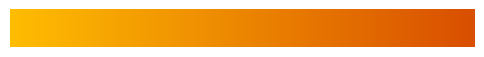

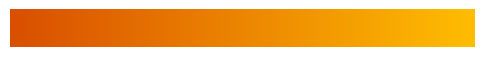

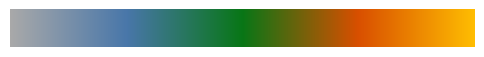

In [59]:
if graph_media == "paper":  
  # Screen
  # Create a linear colormap
  cmap_one = mcolors.LinearSegmentedColormap.from_list("One", [graph_palette['foreground']['duskBlue'], graph_palette['foreground']['oliveLeaf']])
  cmap_two = mcolors.LinearSegmentedColormap.from_list("Two", [graph_palette['foreground']['oliveLeaf'], graph_palette['foreground']['duskBlue']])


else:
  # Screen
  # Create a linear colormap
  cmap_one = mcolors.LinearSegmentedColormap.from_list("GoldToBurnOrange", [graph_palette['foreground']['gold'], graph_palette['foreground']['burntOrange']])
  cmap_two = mcolors.LinearSegmentedColormap.from_list("BurntOrangetoGold", [graph_palette['foreground']['burntOrange'], graph_palette['foreground']['gold']])
  
  mapping_list = [graph_palette['foreground']['lightGrey'],
                  graph_palette['foreground']['steelBlue'],
                  graph_palette['foreground']['green'],
                  graph_palette['foreground']['burntOrange'],
                  graph_palette['foreground']['gold']]
  
  cmap_three = mcolors.LinearSegmentedColormap.from_list("MappingCmap", mapping_list)



# Visualize the gradient ---
fig, ax = plt.subplots(figsize=(6, 1))
fig.subplots_adjust(bottom=0.5)

# Create gradient data
gradient = np.linspace(0, 1, 256).reshape(1, -1)
ax.imshow(gradient, aspect="auto", cmap=cmap_one )
ax.set_axis_off()
plt.show()

fig, ax = plt.subplots(figsize=(6, 1))
fig.subplots_adjust(bottom=0.5)

# Create gradient data
gradient = np.linspace(0, 1, 256).reshape(1, -1)
ax.imshow(gradient, aspect="auto", cmap=cmap_two )
ax.set_axis_off()
plt.show()

fig, ax = plt.subplots(figsize=(6, 1))
fig.subplots_adjust(bottom=0.5)

# Create gradient data
gradient = np.linspace(0, 1, 256).reshape(1, -1)
ax.imshow(gradient, aspect="auto", cmap=cmap_three )
ax.set_axis_off()
plt.show()


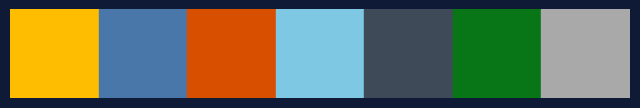

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Background colours from your palette
bg = graph_palette['figure']['bgcolour']   # e.g. "#0F1A37"
linecol = graph_palette['figure']['lines']
textcol = graph_palette['figure']['lines']

# Extract foreground colours
foreground_colours = list(graph_palette["foreground"].values())
sns_palette = sns.color_palette(foreground_colours)

# Create figure with extra padding for outer background
fig, ax = plt.subplots(figsize=(8, 2))
fig.patch.set_facecolor(bg)   # wider outer background
ax.set_facecolor(bg)          # inner axes background

# Draw squares with no gaps
n = len(sns_palette)
for i, color in enumerate(sns_palette):
    ax.add_patch(
        plt.Rectangle(
            (i, 0), 1, 1, 
            facecolor=color, 
            edgecolor=color   # edge same as fill → no white lines
        )
    )

# Formatting to make them squares
ax.set_xlim(0, n)
ax.set_ylim(0, 1)
ax.set_aspect('equal')   # ensures squares, not stretched rectangles
ax.axis("off")

plt.show()


from matplotlib.colors import ListedColormap

map_colours = foreground_colours.copy()
map_colours.reverse()

mapping_cmap= ListedColormap(map_colours, name="my_palette")


  


## Graphs for Presentation

Need to create:

- Objects added by year, showing remaining in orbit
- Pie chart: Breakdown of objects by category (satellites, rocket bodies, debris).
- Bar chart: Payload categories (military, comms, scientific, etc.).
- Bar chart or map: Top countries or organisations responsible for objects in orbit.
- Histogram: Time between launch and re-entry for satellites.
- Visual: Timeline or scatter plot of known collisions or near misses. ... where do we get this data?


Create some filtered datasets

In [18]:
# Filter dataframe for satellites still in orbit
sdf_in_orbit = sdf[sdf['In Orbit'] == True]

# Filter for Type == 'Payload'
sdf_payloads_in_orbit = sdf_in_orbit[sdf_in_orbit['Type'] == 'Payload']

# Filter for Type == 'Payload'
sdf_all_payloads = sdf[sdf['Type'] == 'Payload']


# Ensure dates are parsed
sdf['Launch Date'] = pd.to_datetime(sdf['Launch Date'], errors='coerce')

# Filter for objects still in orbit
in_orbit_df = sdf[sdf['In Orbit'] == True].dropna(subset=['Launch Date'])

# Group by year for cumulative count
cumulative_by_year = in_orbit_df.groupby(in_orbit_df['Launch Date'].dt.year).size().cumsum()

# Group by year for launches (all objects)
launches_by_year = sdf.dropna(subset=['Launch Date']).groupby(sdf['Launch Date'].dt.year).size()


In [19]:
sdf_in_orbit.shape

(32410, 52)

## Objects added by year, showing remaining in orbit

In [20]:
fig = go.Figure()

# Add cumulative line
fig.add_trace(go.Scatter(
    x=cumulative_by_year.index,
    y=cumulative_by_year.values,
    #mode='lines+markers',
    mode='lines',
    name='Cumulative In Orbit',
    line=dict(color='#4977AA', width=3),
    marker=dict(color=linecol, size=6)
))

# Add yearly launches as bars
fig.add_trace(go.Bar(
    x=launches_by_year.index,
    y=launches_by_year.values,
    name='Launches per Year',
    marker_color='#FFBD02'
))

# Apply custom styling
fig.update_layout(
    title='Launches vs Cumulative Objects In Orbit',
    title_font=dict(color='#FFBD02', size=22),
    plot_bgcolor='#0F1A38',
    paper_bgcolor='#0F1A38',
    font=dict(color=linecol),
    xaxis=dict(title='Year', color=linecol, gridcolor=linecol),
    yaxis=dict(title='Count', color=linecol, gridcolor=linecol),
    legend=dict(font=dict(color=linecol)),
    barmode='overlay',
    width=1200,
    height=500
)

fig.show()

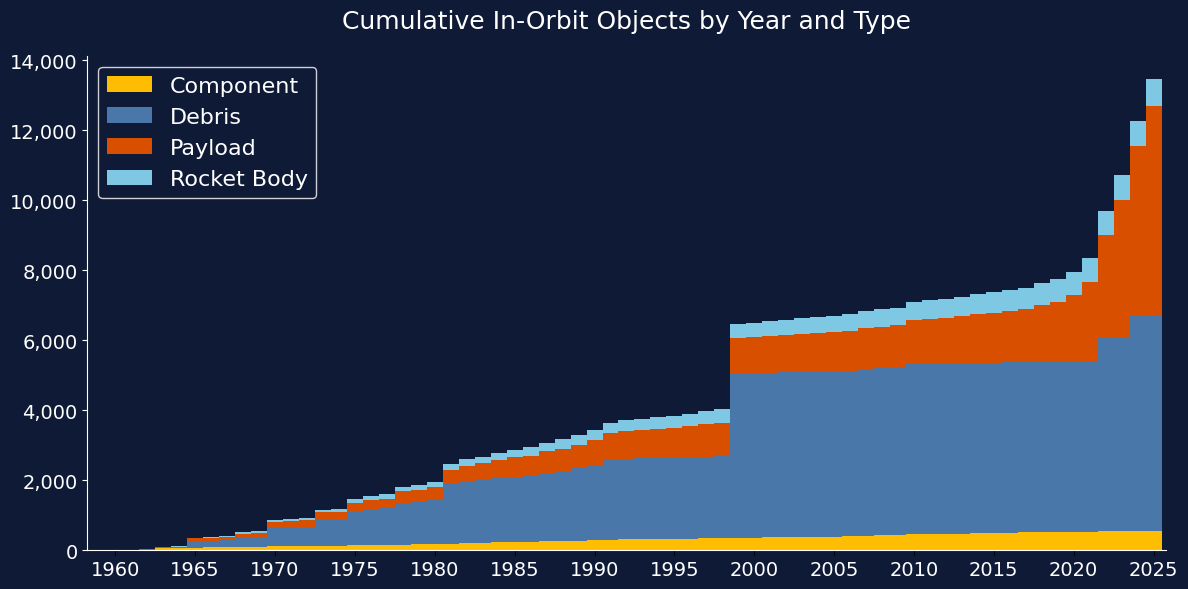

In [21]:
# Step 1: Filter for satellites currently in orbit
df_orbit = sdf_in_orbit[sdf_in_orbit["In Orbit"] == True].copy()

# Step 2: Extract launch year (assuming you have a 'Launch Date' column)
df_orbit["Year"] = pd.to_datetime(df_orbit["Launch Date"]).dt.year

# Step 3: Count objects by Year + Type
counts_by_year_type = (
    df_orbit.groupby(["Year", "Type"])
    .size()
    .reset_index(name="Count")
)

# Step 4: Pivot to wide format
pivot_counts = counts_by_year_type.pivot(index="Year", columns="Type", values="Count").fillna(0)

# Step 5: Compute cumulative counts over time
pivot_cumulative = pivot_counts.cumsum()

# Step 6: Plot stacked bar chart
fig, ax = plt.subplots(figsize=(12, 6), facecolor=bg)
ax.set_facecolor(bg)

pivot_cumulative.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=foreground_colours[:len(pivot_cumulative.columns)],
    width=1.0
)

# Get the years as an array
years = pivot_cumulative.index.astype(int).to_numpy()

# Find positions where the year is a multiple of 5 (adjust start if needed)
mask = (years % 5 == 0)

# Positions on the axis are 0..len(years)-1
positions = np.arange(len(years))[mask]
tick_labels = years[mask]

ax.set_xticks(positions)
ax.set_xticklabels(tick_labels, color=linecol, rotation=0, fontsize=14)
ax.set_xlabel("", labelpad=0)

# Styling (unchanged)
ax.set_title("Cumulative In-Orbit Objects by Year and Type", color=linecol, fontsize=18, pad=20)
#ax.set_ylabel("Cumulative Number of Objects", color=linecol, fontsize=14)
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
ax.tick_params(axis="y", colors=linecol, labelsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(linecol)
ax.spines['bottom'].set_color(linecol)

legend = plt.legend( labelcolor=linecol, fontsize=16)
legend.get_frame().set_facecolor(bg)
legend.get_frame().set_edgecolor(linecol)

plt.tight_layout()
plt.show()


In [22]:
pivot_counts

Type,Component,Debris,Payload,Rocket Body
Year,,,,
1959.0,0.0,0.0,4.0,0.0
1960.0,4.0,1.0,3.0,2.0
1961.0,5.0,0.0,3.0,0.0
1962.0,5.0,0.0,6.0,1.0
1963.0,41.0,4.0,8.0,2.0
...,...,...,...,...
2021.0,3.0,1.0,372.0,11.0
2022.0,5.0,648.0,677.0,27.0
2023.0,7.0,3.0,992.0,20.0


In [23]:
pivot_cumulative

Type,Component,Debris,Payload,Rocket Body
Year,,,,
1959.0,0.0,0.0,4.0,0.0
1960.0,4.0,1.0,7.0,2.0
1961.0,9.0,1.0,10.0,2.0
1962.0,14.0,1.0,16.0,3.0
1963.0,55.0,5.0,24.0,5.0
...,...,...,...,...
2021.0,535.0,4878.0,2265.0,660.0
2022.0,540.0,5526.0,2942.0,687.0
2023.0,547.0,5529.0,3934.0,707.0


## Breakdown of objects by category (satellites, rocket bodies, debris).

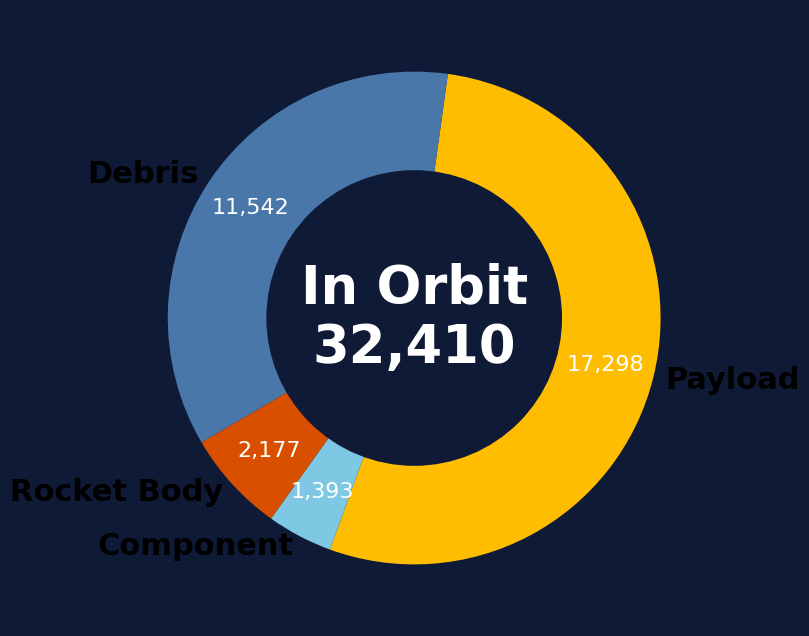

In [24]:
# Count by Type
type_counts = sdf_in_orbit['Type'].value_counts()

# Create figure
fig, ax = plt.subplots(figsize=(8, 8), facecolor=bg)
ax.set_facecolor(bg)

# Donut chart
wedges, texts, autotexts = ax.pie(
    type_counts,
    labels=type_counts.index,
    #autopct='%1.1f%%',
    autopct=lambda pct: f"{int(round(pct/100.*type_counts.sum())):,}",  # show counts
    pctdistance=0.80,    # move counts outward
    labeldistance=1.05,    # move labels outward
    startangle=250,
    colors=foreground_colours[:len(type_counts)],
    textprops={'fontsize': 16}
)

# Set category labels (around chart) to black
for t in texts:
    t.set_color("black")
    t.set_fontsize(22)
    t.set_fontweight('bold')

# Set value labels (inside chart) to white
for at in autotexts:
    at.set_color("white")

# Make it a Donut Plot
centre_circle = plt.Circle((0, 0), 0.60, fc=bg)
fig.gca().add_artist(centre_circle)

# Add centre annotation
plt.text(0, 0, f"In Orbit\n{type_counts.sum():,}", ha='center', va='center',
         color=linecol, fontsize=38, fontweight='bold')

plt.show()

## Payload categories (military, comms, scientific, etc.).

**Donut Chart**

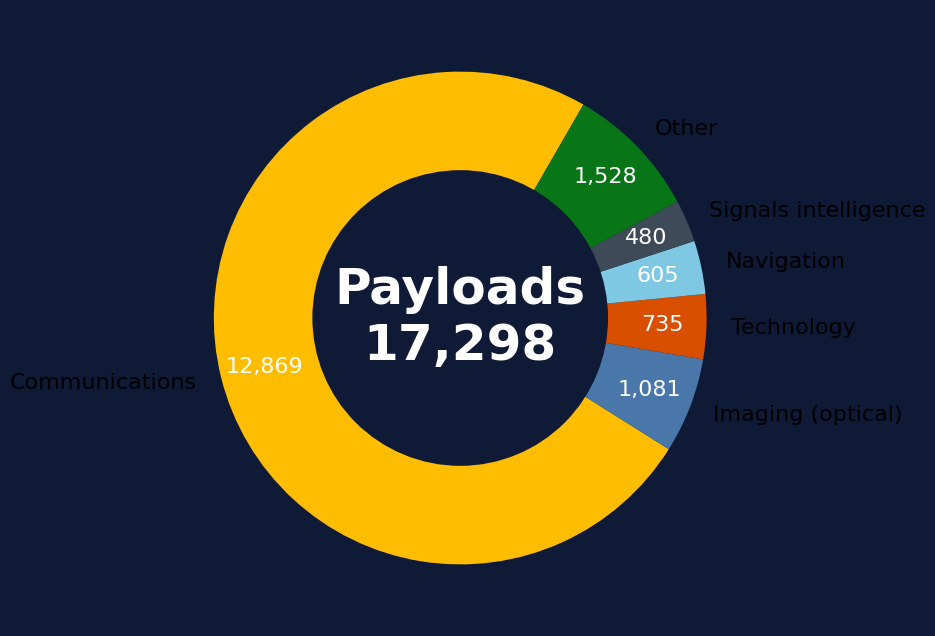

In [25]:
# Count by Category
category_counts_orbit = sdf_payloads_in_orbit['Primary Category'].value_counts()

# Keep top 5 and combine the rest into "Other"
top_n = 5
top_categories = category_counts_orbit[:top_n]
other_sum = category_counts_orbit[top_n:].sum()

# Append "Other" if there are remaining categories
if other_sum > 0:
    top_categories['Other'] = other_sum

# Create figure with darkBlue background
fig, ax = plt.subplots(figsize=(8, 8), facecolor=bg)
ax.set_facecolor(bg)

# Donut chart
wedges, texts, autotexts = ax.pie(
    top_categories,
    labels=top_categories.index,
    autopct=lambda pct: f"{int(round(pct/100.*top_categories.sum())):,}",  # show counts
    startangle=60,
    colors=foreground_colours[:len(top_categories)],
    textprops={'fontsize': 16},
    pctdistance=0.82,    # move counts outward
    labeldistance=1.1    # move labels outward
)
ax.set_aspect('equal')

# Set category labels (around chart) to black
for t in texts:
    t.set_color("black")

# Set value labels (inside chart) to white
for at in autotexts:
    at.set_color("white")

# Make it a donut
centre_circle = plt.Circle((0, 0), 0.60, fc=bg)
fig.gca().add_artist(centre_circle)

# Add centre annotation
plt.text(0, 0, f"Payloads\n{top_categories.sum():,}", ha='center', va='center',
         color=linecol, fontsize=36, fontweight='bold')

plt.show()


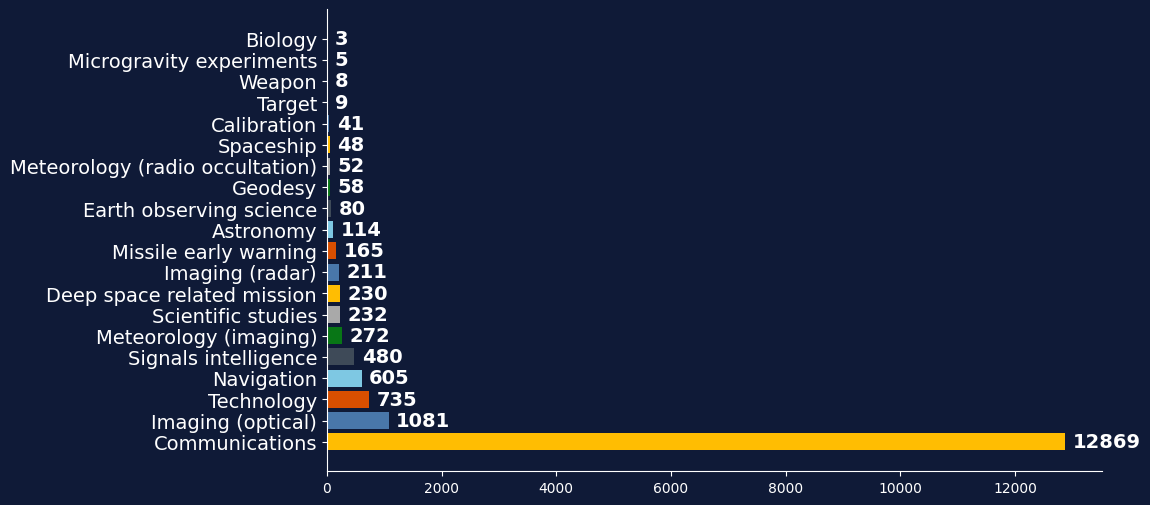

In [26]:
# Count by Category
category_counts_orbit = sdf_payloads_in_orbit['Primary Category'].value_counts()

# Create figure with darkBlue background
fig, ax = plt.subplots(figsize=(10, 6), facecolor=bg)
ax.set_facecolor(bg)

# Horizontal bar chart
bars = ax.barh(
    category_counts_orbit .index,
    category_counts_orbit .values,
    color=foreground_colours[:len(category_counts_orbit )]
)

# Add counts on bars
for bar, count in zip(bars, category_counts_orbit .values):
    ax.text(
        count + max(category_counts_orbit .values)*0.01,  # small offset
        bar.get_y() + bar.get_height()/2,
        str(count),
        va='center',
        color=linecol,
        fontsize=14,
        fontweight='bold'
    )

# Style axes
ax.tick_params(axis='y', colors=linecol, labelsize=14)
ax.tick_params(axis='x', colors=linecol)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(linecol)
ax.spines['bottom'].set_color(linecol)

plt.show()


## Type of Payload

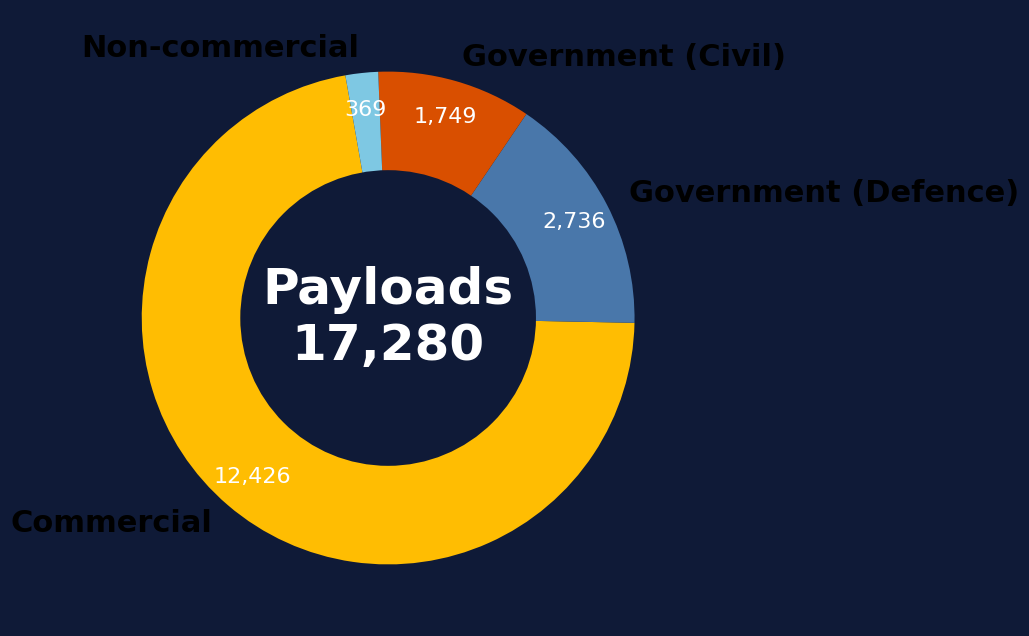

In [27]:
# Count by Class
class_counts_orbit = sdf_payloads_in_orbit['Class'].value_counts()

# Create figure with darkBlue background
fig, ax = plt.subplots(figsize=(8, 8), facecolor=bg)
ax.set_facecolor(bg)

# Donut chart
wedges, texts, autotexts = ax.pie(
    class_counts_orbit,
    labels=class_counts_orbit.index,
    autopct=lambda pct: f"{int(round(pct/100.*class_counts_orbit.sum())):,}",  # show counts
    startangle=100,
    colors=foreground_colours[:len(class_counts_orbit)],
    textprops={'fontsize': 16},
    pctdistance=0.85,    # move counts outward
    labeldistance=1.1    # move labels outward
)
ax.set_aspect('equal')

# Set category labels (around chart) to black
for t in texts:
    t.set_color("black")
    t.set_fontsize(22)
    t.set_fontweight('bold')

# Set value labels (inside chart) to white
for at in autotexts:
    at.set_color("white")

# Make it a donut
centre_circle = plt.Circle((0, 0), 0.60, fc=bg)
fig.gca().add_artist(centre_circle)

# Add centre annotation
plt.text(0, 0, f"Payloads\n{class_counts_orbit.sum():,}", ha='center', va='center',
         color=linecol, fontsize=36, fontweight='bold')

plt.show()

## Operators and Origins - Masses

In [28]:

# Total mass of all satellites
total_mass = sdf_payloads_in_orbit["Mass"].sum() /1000
print("Total Mass:", total_mass, "metric tons")
print ()

# Total mass by country
mass_by_country = sdf_payloads_in_orbit.groupby("Country")["Mass"].sum()
print (mass_by_country.head(10))
print ()

# Total mass by category
mass_by_category = sdf_payloads_in_orbit.groupby("Primary Category")["Mass"].sum()
print (mass_by_category)


Total Mass: 13174.409474000002 metric tons

Country
Algeria        5633.00
Angola         3797.00
Argentina     15657.50
Australia     41718.50
Austria          18.00
Azerbaijan     6738.25
Bahrain           3.00
Bangladesh     3700.00
Belarus        5204.00
Bermuda        8099.00
Name: Mass, dtype: float64

Primary Category
Astronomy                           111514.220
Biology                                259.000
Calibration                           6363.000
Communications                     9087221.619
Deep space related mission          270547.700
Earth observing science              50849.600
Geodesy                              40845.000
Imaging (optical)                   830808.440
Imaging (radar)                     202136.000
Meteorology (imaging)               304870.000
Meteorology (radio occultation)       4403.000
Microgravity experiments               580.000
Missile early warning               238306.000
Navigation                          606928.000
Scientific stud

### Overall Mass in Orbit

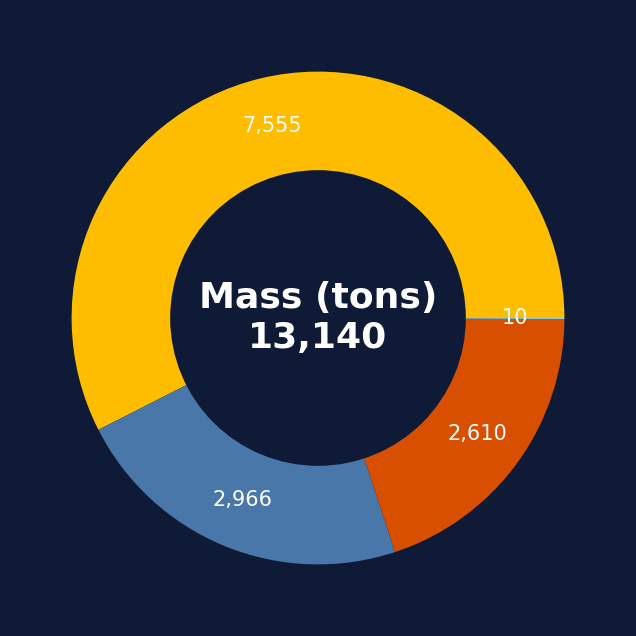

In [29]:
# Aggregate total mass by Class and convert to metric tons
class_mass_orbit = sdf_payloads_in_orbit.groupby("Class")["Mass"].sum().sort_values(ascending=False) /1000

# SCreate figure with dark background
fig, ax = plt.subplots(figsize=(8, 8), facecolor=bg)
ax.set_facecolor(bg)

# Donut chart of mass by Class
wedges, texts, autotexts = ax.pie(
    class_mass_orbit,
    #labels=class_mass_orbit.index,
    labels=None,
    autopct=lambda pct: f"{int(round(pct/100.*class_mass_orbit.sum())):,}",  # show mass values
    startangle=0,
    colors=foreground_colours[:len(class_mass_orbit)],
    textprops={'color': linecol, 'fontsize': 15},
    pctdistance=0.80,
    labeldistance=1.1
)
ax.set_aspect('equal')

# Make it a donut using background coloured circle
centre_circle = plt.Circle((0, 0), 0.60, fc=bg)
fig.gca().add_artist(centre_circle)

# Add centre annotation with total mass
plt.text(
    0, 0,
    f"Mass (tons)\n{int(class_mass_orbit.sum()):,}",   # formatted with commas
    ha='center', va='center',
    color=linecol, fontsize=26, fontweight='bold'
)

plt.show()

### Overall Mass in Orbit (Top 5 Countries)

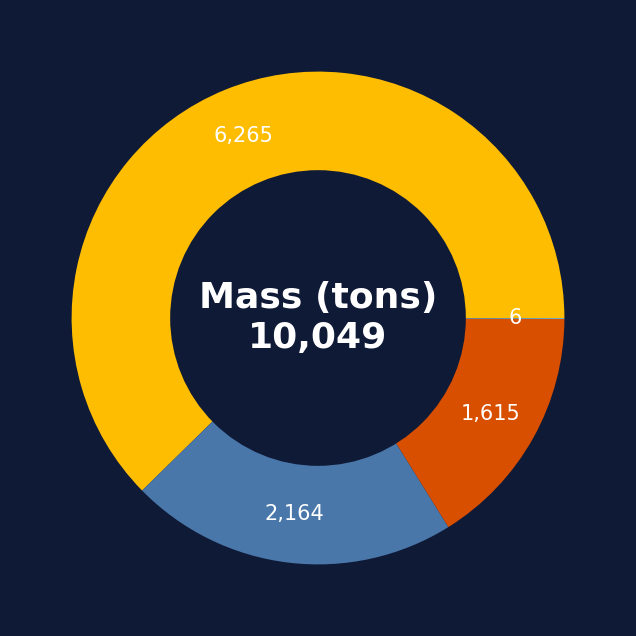

In [30]:
# Find top 5 countries by total mass
country_mass_orbit = (
    sdf_payloads_in_orbit.groupby("Country")["Mass"]
    .sum()
    .sort_values(ascending=False)
)
top5_countries = country_mass_orbit.head(5).index

# Filter dataset to only those countries
df_top5 = sdf_payloads_in_orbit[sdf_payloads_in_orbit["Country"].isin(top5_countries)]

# Aggregate total mass by Class (within top 5 countries)
# Convert to metric tons
class_mass_top5 = (
    df_top5.groupby("Class")["Mass"] 
    .sum()
    .sort_values(ascending=False) /1000
)

# Create figure with dark background
fig, ax = plt.subplots(figsize=(8, 8), facecolor=bg)
ax.set_facecolor(bg)

# Donut chart of mass by Class (top 5 countries only)
wedges, texts, autotexts = ax.pie(
    class_mass_top5,
    labels=None,   # no text labels
    autopct=lambda pct: f"{int(round(pct/100.*class_mass_top5.sum())):,}",  # show mass values
    startangle=0,
    colors=foreground_colours[:len(class_mass_top5)],
    textprops={'color': linecol, 'fontsize': 15},
    pctdistance=0.80,
    labeldistance=1.1
)
ax.set_aspect('equal')

# Make it a donut using circle
centre_circle = plt.Circle((0, 0), 0.60, fc=bg)
fig.gca().add_artist(centre_circle)

# Add centre annotation with total mass
plt.text(
    0, 0,
    f"Mass (tons)\n{int(class_mass_top5.sum()):,}",   # formatted with commas
    ha='center', va='center',
    color=linecol, fontsize=26, fontweight='bold'
)

plt.show()


Mass by Project / Program

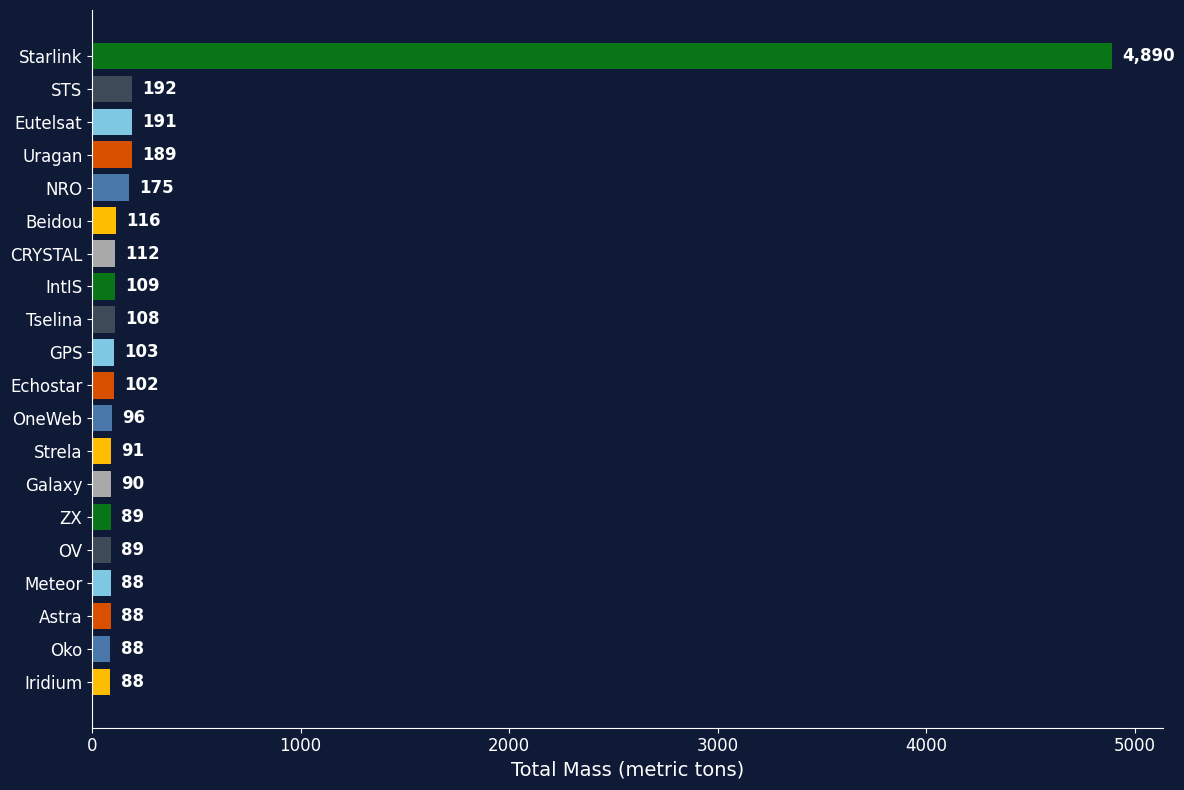

In [31]:
# Aggregate total mass by Program Root (Project), convert to tons
mass_by_program = (
    sdf_payloads_in_orbit.groupby("Program Root")["Mass"]
    .sum()
    .sort_values(ascending=True) 
    .tail(20) / 1000                   
)

# Create figure
fig, ax = plt.subplots(figsize=(12, 8), facecolor=bg)
ax.set_facecolor(bg)

# Plot horizontal bar chart
bars = ax.barh(
    mass_by_program.index,
    mass_by_program.values,
    color=foreground_colours[:len(mass_by_program)]
)

# Add labels at end of bars
for bar, value in zip(bars, mass_by_program.values):
    ax.text(
        value + max(mass_by_program.values)*0.01,   # small offset
        bar.get_y() + bar.get_height()/2,
        f"{int(value):,}",                        # formatted with commas
        va="center",
        color=linecol,
        fontsize=12,
        fontweight="bold"
    )

# Style axes
#ax.set_title("Top 20 Programs by Total Satellite Mass", color=linecol, fontsize=18, pad=20)
ax.set_xlabel("Total Mass (metric tons)", color=linecol, fontsize=14)
ax.tick_params(axis="y", colors=linecol, labelsize=12)
ax.tick_params(axis="x", colors=linecol, labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(linecol)
ax.spines['bottom'].set_color(linecol)

plt.tight_layout()
plt.show()


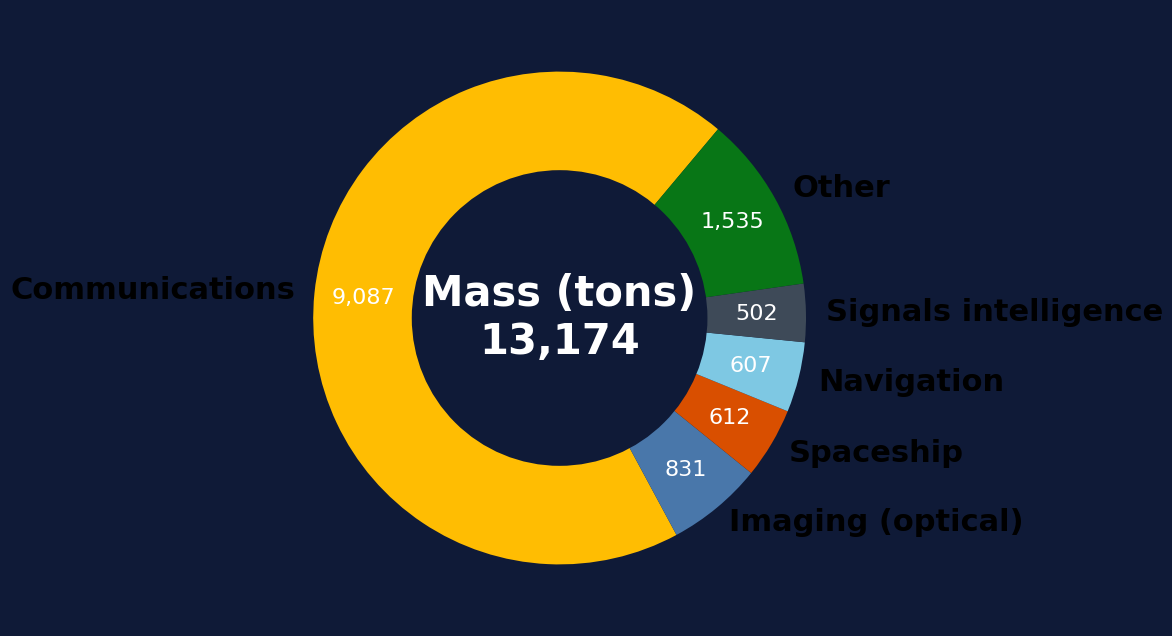

In [32]:
# Aggregate total mass by Primary Category, convert to tons
category_mass_orbit = (
    sdf_payloads_in_orbit.groupby("Primary Category")["Mass"]
    .sum()
    .sort_values(ascending=False) /1000
)

# Keep top 5 and combine the rest into "Other"
top_n = 5
top_categories = category_mass_orbit[:top_n]
other_sum = category_mass_orbit[top_n:].sum()

if other_sum > 0:
    top_categories["Other"] = other_sum

# Create figure with dark background
fig, ax = plt.subplots(figsize=(8, 8), facecolor=bg)
ax.set_facecolor(bg)

# Donut chart of mass by top 5 categories
wedges, texts, autotexts = ax.pie(
    top_categories,
    labels=top_categories.index,
    autopct=lambda pct: f"{int(round(pct/100.*top_categories.sum())):,}",  # show mass values
    startangle=50,
    colors=foreground_colours[:len(top_categories)],
    textprops={'fontsize': 16},
    pctdistance=0.8,
    labeldistance=1.08
)
ax.set_aspect('equal')


# Set category labels (around chart) to black
for t in texts:
    t.set_color("black")
    t.set_fontsize(22)
    t.set_fontweight('bold')

# Set value labels (inside chart) to white
for at in autotexts:
    at.set_color("white")

# Make it a donut
centre_circle = plt.Circle((0, 0), 0.60, fc=bg)
fig.gca().add_artist(centre_circle)

# Add centre annotation with total mass
plt.text(
    0, 0,
    f"Mass (tons)\n{int(top_categories.sum()):,}",
    ha='center', va='center',
    color=linecol, fontsize=30, fontweight='bold'
)

plt.show()


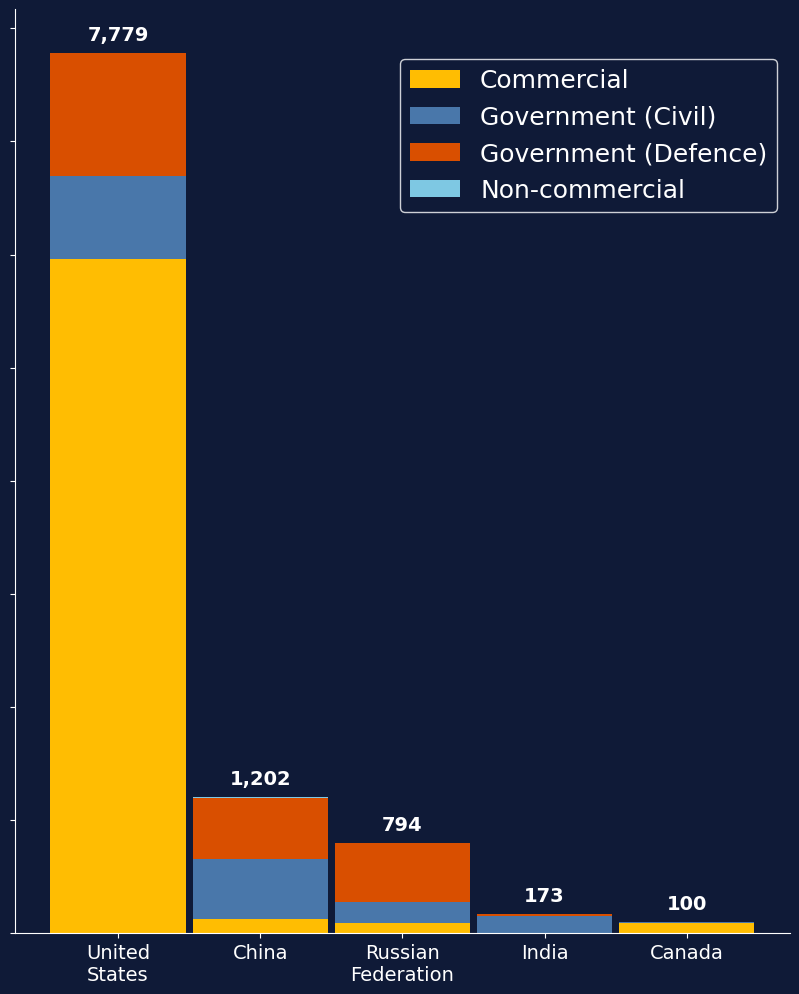

In [33]:
# Aggregate total mass per country
country_mass = sdf_payloads_in_orbit.groupby("Country")["Mass"].sum().sort_values(ascending=False)

# Select top 5 countries, then reverse order (smallest → largest)
top_countries = country_mass.head(5).sort_values(ascending=False).index

# Filter data for those countries
df_top = sdf_payloads_in_orbit[sdf_payloads_in_orbit["Country"].isin(top_countries)]

# Aggregate mass by Country + Class
mass_by_country_class = df_top.groupby(["Country", "Class"])["Mass"].sum().reset_index()
# Convert to tons
mass_by_country_class["Mass"] = mass_by_country_class["Mass"] / 1000

# Pivot for stacked bar chart
pivot_data = mass_by_country_class.pivot(index="Country", columns="Class", values="Mass").fillna(0)

# Reindex to enforce ascending order
pivot_data = pivot_data.loc[top_countries]

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(10, 12), facecolor=bg)
ax.set_facecolor(bg)

# This chart requires custom foreground colour ordering to match with the other chart on the same page
# Attention to detail! :)

# **********

#temp_foreground_colours = [
#    graph_palette['foreground']['green'],
#    graph_palette['foreground']['green'],
#    graph_palette['foreground']['green'],
#    graph_palette['foreground']['green'],
#]

pivot_data.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.95,
    color=foreground_colours[:len(pivot_data.columns)]
)

# Compute totals for each column (country)
totals = pivot_data.sum(axis=1)
# Annotate totals above each bar
for i, total in enumerate(totals):
    ax.text(
        i, total + (0.01 * totals.max()),   # add 1% of max as vertical gap
        f"{total:,.0f}", 
        ha="center", va="bottom",
        color=linecol, fontsize=14, fontweight="bold"
    )

# Replace the offset text with custom string
ax.yaxis.get_offset_text().set_visible(False)   # hide the 1e7

# Replace spaces with newlines for stacked labels
labels = [label.replace(" ", "\n") for label in pivot_data.index]

# Apply labels with horizontal centering
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(
    labels,
    color=linecol,
    fontsize=12,
    rotation=0,      # keep horizontal
    ha="center"      # center align under tick
)

ax.set_yticklabels([])   # hides the labels but keeps tick marks


ax.xaxis.label.set_visible(False)
ax.tick_params(axis="x", colors=linecol, labelsize=14, rotation=0)
ax.tick_params(axis="y", colors=linecol, labelsize=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(linecol)
ax.spines['bottom'].set_color(linecol)

legend = plt.legend(labelcolor=linecol, fontsize=18, loc="upper right", bbox_to_anchor=(1, 0.96))
legend.get_frame().set_facecolor(bg)   # set legend background to bg
legend.get_frame().set_edgecolor(linecol)  
plt.show()


Didn't use this one

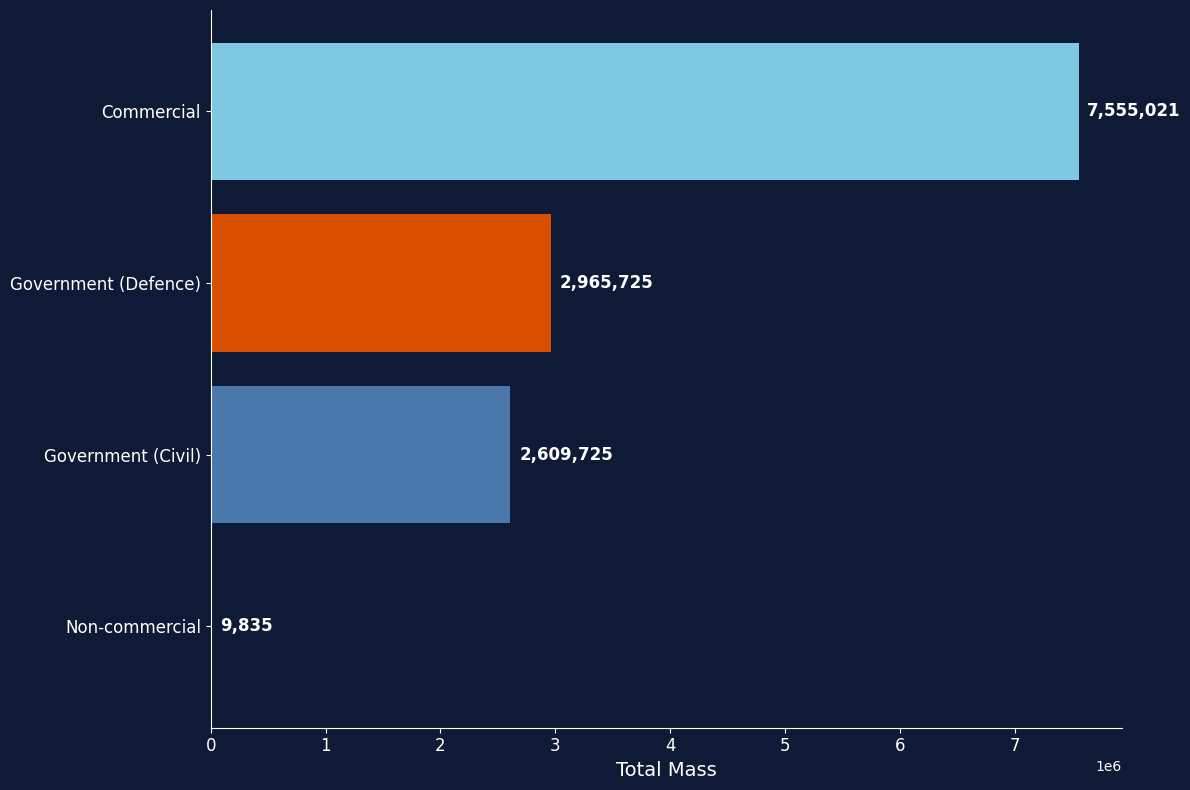

In [34]:
import matplotlib.pyplot as plt

# Step 1: Aggregate total mass by Class
mass_by_class = (
    sdf_payloads_in_orbit.groupby("Class")["Mass"]
    .sum()
    .sort_values(ascending=True)   # ascending so smallest at top
)

# Step 2: Create figure
fig, ax = plt.subplots(figsize=(12, 8), facecolor=bg)
ax.set_facecolor(bg)

# Step 3: Plot horizontal bar chart
bars = ax.barh(
    mass_by_class.index,
    mass_by_class.values,
    color=foreground_colours[:len(mass_by_class)]
)

# Step 4: Add labels at end of bars
for bar, value in zip(bars, mass_by_class.values):
    ax.text(
        value + max(mass_by_class.values)*0.01,   # small offset
        bar.get_y() + bar.get_height()/2,
        f"{int(value):,}",                        # formatted with commas
        va="center",
        color=linecol,
        fontsize=12,
        fontweight="bold"
    )

# Step 5: Style axes
#ax.set_title("Total Satellite Mass by Class", color=linecol, fontsize=18, pad=20)
ax.set_xlabel("Total Mass", color=linecol, fontsize=14)
ax.tick_params(axis="y", colors=linecol, labelsize=12)
ax.tick_params(axis="x", colors=linecol, labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(linecol)
ax.spines['bottom'].set_color(linecol)

plt.tight_layout()
plt.show()


### Program Growth by Year

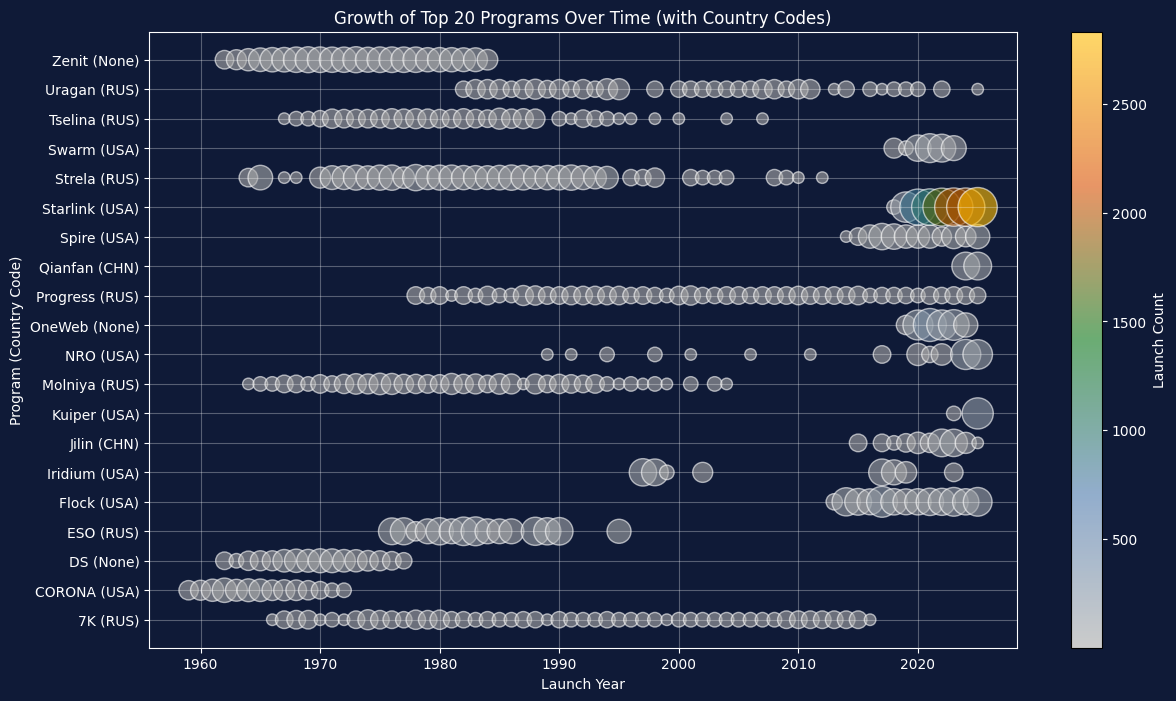

In [60]:
import matplotlib.pyplot as plt

# Count launches per Program Root per year
program_counts = (
    sdf.groupby(["Program Root", "Launch Year"])
    .size()
    .reset_index(name="count")
)

# Get top 20 programs overall
top_programs = (
    program_counts.groupby("Program Root")["count"].sum()
    .nlargest(20)
    .index
)

program_counts = program_counts[program_counts["Program Root"].isin(top_programs)]

# --- Build labels with Program Root + Country Code ---
# Take the first country code seen for each program
program_labels = (
    sdf[sdf["Program Root"].isin(top_programs)]
    .groupby("Program Root")["Country Code"]
    .first()
    .to_dict()
)

# Create new label column
program_counts["Program Label"] = program_counts["Program Root"].map(
    lambda p: f"{p} ({program_labels.get(p, '')})"
)

# Bubble chart
fig, ax = plt.subplots(figsize=(14,8))
fig.patch.set_facecolor(bg)        # background color
ax.set_facecolor(bg)

scatter = ax.scatter(
    program_counts["Launch Year"],
    program_counts["Program Label"],
    s=np.log1p(program_counts["count"]) * 100,  # log scaling
    alpha=0.6,
    c=program_counts["count"],
    cmap=cmap_three,
    edgecolors=linecol
)


ax.set_title("Growth of Top 20 Programs Over Time (with Country Codes)", color=linecol)
ax.set_xlabel("Launch Year", color=linecol)
ax.set_ylabel("Program (Country Code)", color=linecol)
ax.tick_params(colors=linecol)
for spine in ax.spines.values():
    spine.set_color("white")

# Colorbar with white text
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Payload Count', color=linecol)
cbar.ax.yaxis.set_tick_params(color=linecol)
plt.setp(cbar.ax.get_yticklabels(), color=linecol)

ax.grid(True, color=linecol, alpha=0.3)
cbar.set_label("Launch Count")

plt.show()


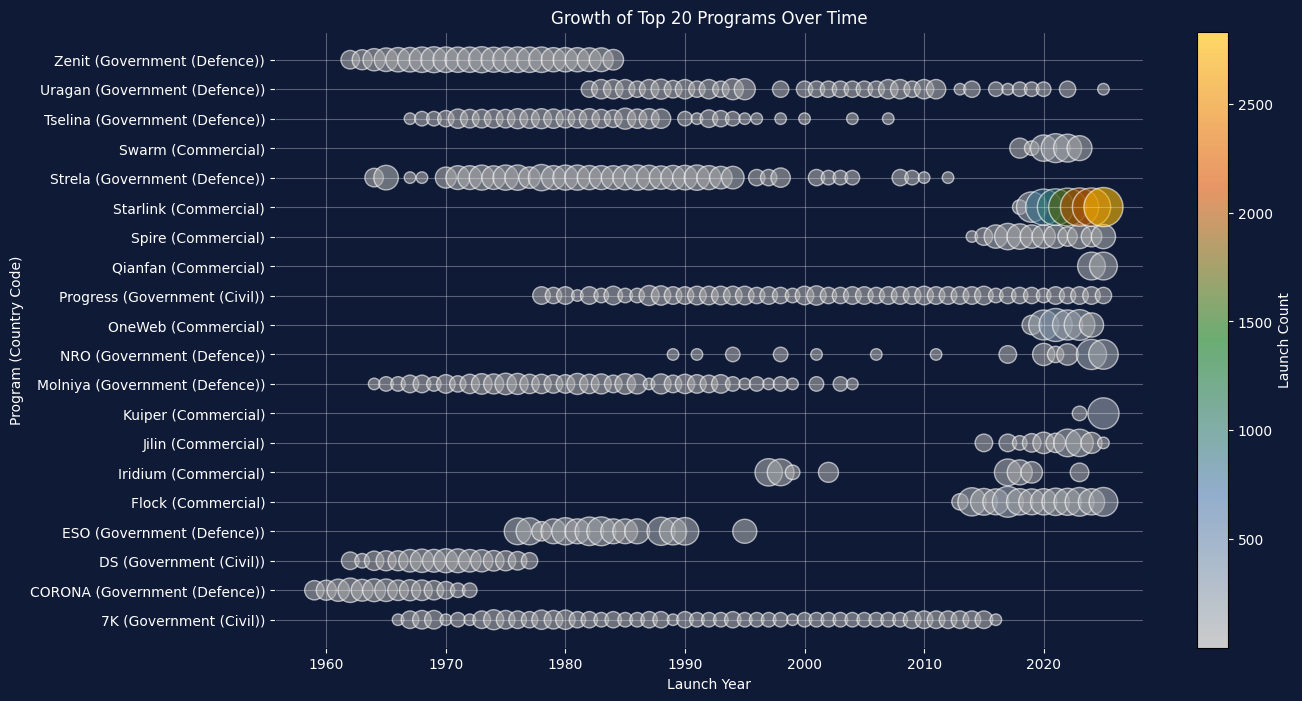

In [61]:
import matplotlib.pyplot as plt

# Count launches per Program Root per year
program_counts = (
    sdf.groupby(["Program Root", "Launch Year"])
    .size()
    .reset_index(name="count")
)

# Get top 20 programs overall
top_programs = (
    program_counts.groupby("Program Root")["count"].sum()
    .nlargest(20)
    .index
)

program_counts = program_counts[program_counts["Program Root"].isin(top_programs)]

# --- Build labels with Program Root + Class ---
# Take the first country code seen for each program
program_labels = (
    sdf[sdf["Program Root"].isin(top_programs)]
    .groupby("Program Root")["Class"]
    .first()
    .to_dict()
)

# Create new label column
program_counts["Program Label"] = program_counts["Program Root"].map(
    lambda p: f"{p} ({program_labels.get(p, '')})"
)

# Bubble chart
fig, ax = plt.subplots(figsize=(14,8))
fig.patch.set_facecolor(bg)        # background color
ax.set_facecolor(bg)

scatter = ax.scatter(
    program_counts["Launch Year"],
    program_counts["Program Label"],
    s=np.log1p(program_counts["count"]) * 100,  # log scaling
    alpha=0.6,
    c=program_counts["count"],
    cmap=cmap_three,
    edgecolors=linecol
)


ax.set_title("Growth of Top 20 Programs Over Time", color=linecol)
ax.set_xlabel("Launch Year", color=linecol)
ax.set_ylabel("Program (Country Code)", color=linecol)
ax.tick_params(colors=linecol)
for spine in ax.spines.values():
    spine.set_color(bg)

# Colorbar with white text
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Payload Count', color=linecol)
cbar.ax.yaxis.set_tick_params(color=linecol)
plt.setp(cbar.ax.get_yticklabels(), color=linecol)

ax.grid(True, color=linecol, alpha=0.3)
cbar.set_label("Launch Count")

plt.show()



In [37]:
import pandas as pd
from tabulate import tabulate

# Filter launches from 2015 onwards
recent = sdf[sdf["Launch Year"] >= 2015].copy()

# Count launches per program
program_counts = (
    recent.groupby("Program Root")["Launch Year"]
    .agg(total_launches="count", first_launch_year="min")
    .reset_index()
)

# Add country code (take the first seen for each program)
country_map = (
    sdf.groupby("Program Root")["Country Code"]
    .first()
    .to_dict()
)
program_counts["Country Code"] = program_counts["Program Root"].map(country_map)

# Top 5 programs by total launches
top5 = program_counts.nlargest(5, "total_launches")

# Pretty table
print(tabulate(top5, headers="keys", tablefmt="fancy_grid"))


╒═════╤════════════════╤══════════════════╤═════════════════════╤════════════════╕
│     │ Program Root   │   total_launches │   first_launch_year │ Country Code   │
╞═════╪════════════════╪══════════════════╪═════════════════════╪════════════════╡
│ 881 │ Starlink       │            10413 │                2018 │ USA            │
├─────┼────────────────┼──────────────────┼─────────────────────┼────────────────┤
│ 656 │ OneWeb         │              656 │                2019 │                │
├─────┼────────────────┼──────────────────┼─────────────────────┼────────────────┤
│ 282 │ Flock          │              584 │                2015 │ USA            │
├─────┼────────────────┼──────────────────┼─────────────────────┼────────────────┤
│ 602 │ NRO            │              231 │                2017 │ USA            │
├─────┼────────────────┼──────────────────┼─────────────────────┼────────────────┤
│ 886 │ Swarm          │              201 │                2018 │ USA            │
╘═══

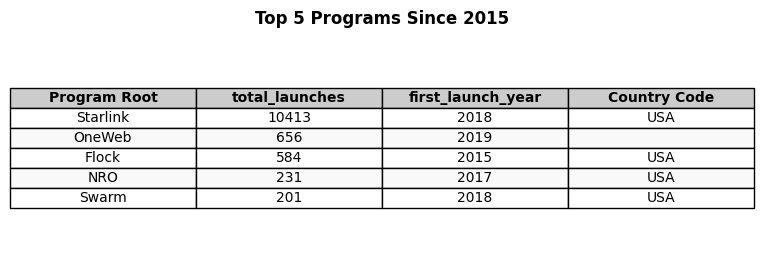

In [38]:
import matplotlib.pyplot as plt

# Assume `top5` is your DataFrame with columns:
# Program Root, Country Code, First Launch Year, Total Launches

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis("off")  # hide axes

# Build table
table = ax.table(
    cellText=top5.values,
    colLabels=top5.columns,
    cellLoc="center",
    loc="center"
)

# Style
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

# Bold headers
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#cccccc")  # header background

# Alternate row colors
for row in range(1, len(top5)+1):
    color = "#f9f9f9" if row % 2 == 0 else linecol
    for col in range(len(top5.columns)):
        table[(row, col)].set_facecolor(color)

plt.title("Top 5 Programs Since 2015", fontsize=12, weight="bold")
plt.show()


Category growth trends

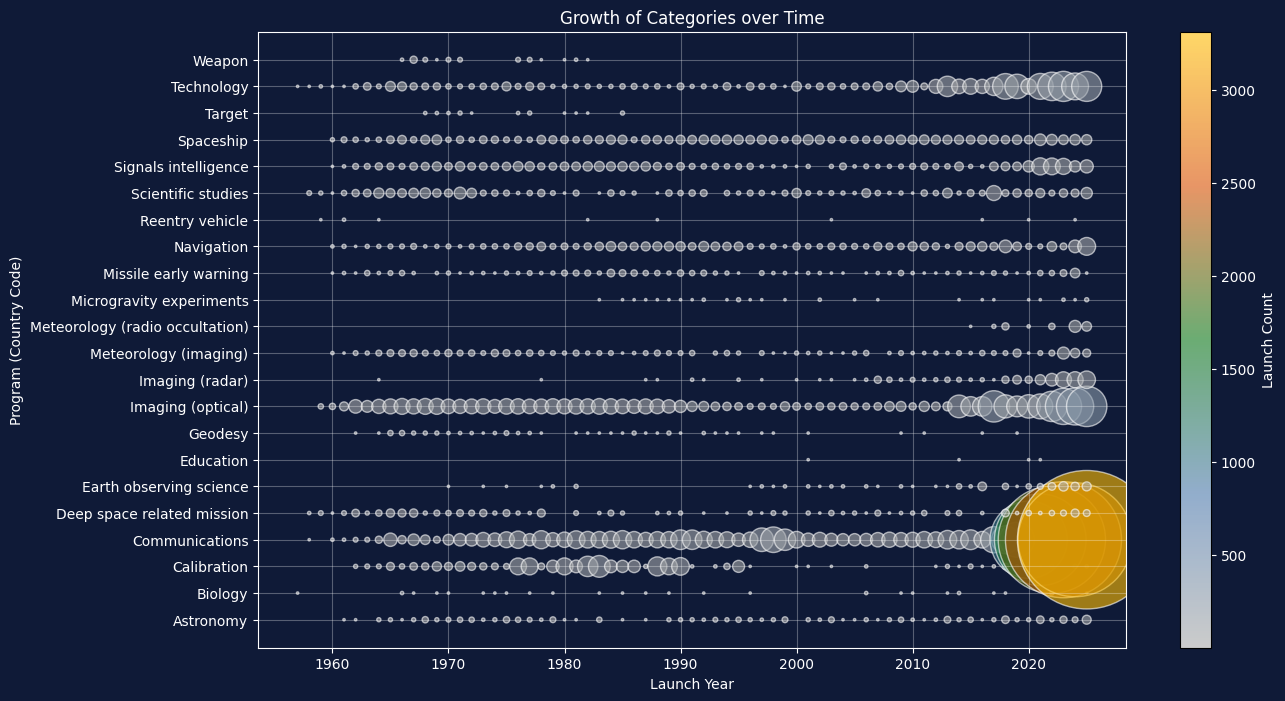

In [62]:
import matplotlib.pyplot as plt

# Count launches per Program Root per year
program_counts = (
    sdf.groupby(["Primary Category", "Launch Year"])
    .size()
    .reset_index(name="count")
)

# Get top 20 programs overall
top_programs = (
    program_counts.groupby("Primary Category")["count"].sum()
    .nlargest(100)
    .index
)

program_counts = program_counts[program_counts["Primary Category"].isin(top_programs)]


# Create new label column
program_counts["Program Label"] = program_counts["Primary Category"].map(
    lambda p: f"{p} ({program_labels.get(p, '')})"
)

# Bubble chart
fig, ax = plt.subplots(figsize=(14,8))
fig.patch.set_facecolor(bg)        # background color
ax.set_facecolor(bg)

scatter = ax.scatter(
    program_counts["Launch Year"],
    program_counts["Primary Category"],
    #s=np.log1p(program_counts["count"]) * 100,  # log scaling
    s=program_counts["count"] * 3,  # log scaling
    alpha=0.6,
    c=program_counts["count"],
    cmap=cmap_three,
    edgecolors=linecol
)


ax.set_title("Growth of Categories over Time", color=linecol)
ax.set_xlabel("Launch Year", color=linecol)
ax.set_ylabel("Program (Country Code)", color=linecol)
ax.tick_params(colors=linecol)
for spine in ax.spines.values():
    spine.set_color(linecol)

# Colorbar with white text
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Payload Count', color=linecol)
cbar.ax.yaxis.set_tick_params(color=linecol)
plt.setp(cbar.ax.get_yticklabels(), color=linecol)

ax.grid(True, color=linecol, alpha=0.3)
cbar.set_label("Launch Count")

plt.show()


Type Growth Trends

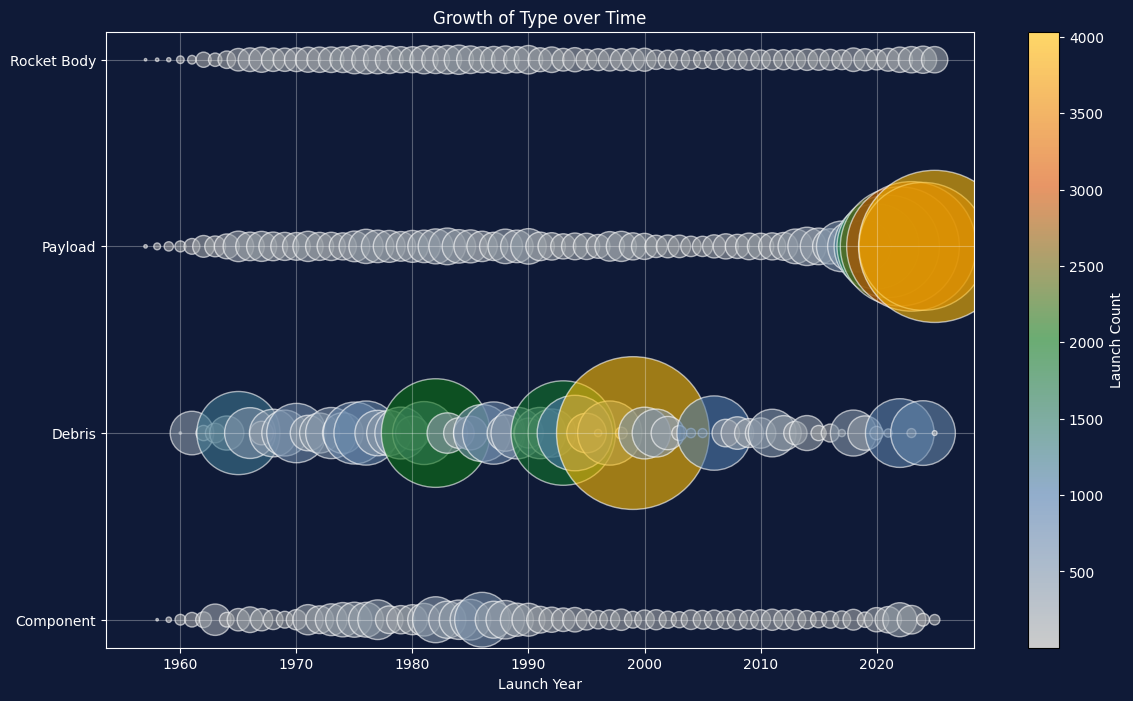

In [63]:
import matplotlib.pyplot as plt

# Count launches per Program Root per year
program_counts = (
    sdf.groupby(["Type", "Launch Year"])
    .size()
    .reset_index(name="count")
)

# Get top 20 programs overall
top_programs = (
    program_counts.groupby("Type")["count"].sum()
    .nlargest(20)
    .index
)

program_counts = program_counts[program_counts["Type"].isin(top_programs)]


# Create new label column
program_counts["Program Label"] = program_counts["Type"].map(
    lambda p: f"{p} ({program_labels.get(p, '')})"
)

# Bubble chart
fig, ax = plt.subplots(figsize=(14,8))
fig.patch.set_facecolor(bg)        # background color
ax.set_facecolor(bg)

scatter = ax.scatter(
    program_counts["Launch Year"],
    program_counts["Type"],
    #s=np.log1p(program_counts["count"]) * 100,  # log scaling
    s=program_counts["count"] * 3, # log scaling
    alpha=0.6,
    c=program_counts["count"],
    cmap=cmap_three,
    edgecolors=linecol
)


ax.set_title("Growth of Type over Time", color=linecol)
ax.set_xlabel("Launch Year", color=linecol)
#ax.set_ylabel("Program (Country Code)", color=linecol)
ax.tick_params(colors=linecol)
for spine in ax.spines.values():
    spine.set_color("white")

# Colorbar with white text
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Payload Count', color=linecol)
cbar.ax.yaxis.set_tick_params(color=linecol)
plt.setp(cbar.ax.get_yticklabels(), color=linecol)

ax.grid(True, color=linecol, alpha=0.3)
cbar.set_label("Launch Count")

plt.show()


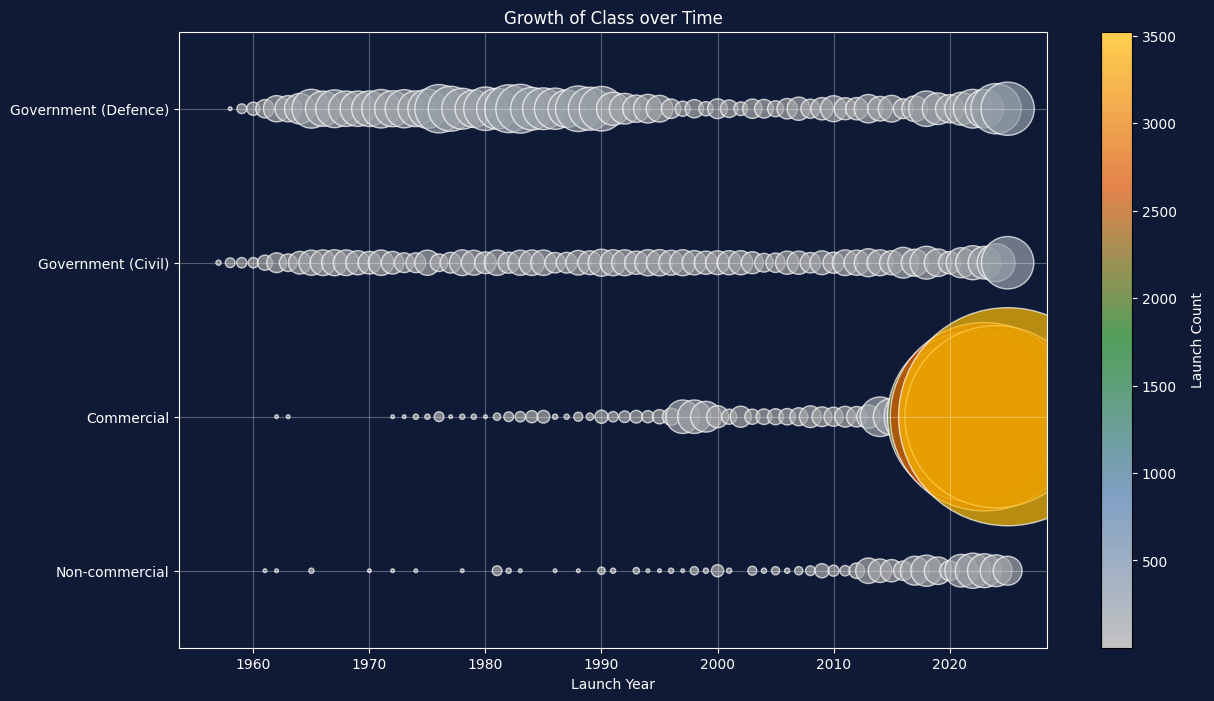

In [64]:
import matplotlib.pyplot as plt
import pandas as pd

# Fix filter (you referenced sdf in the second condition)
filtered = sdf_all_payloads[
    (sdf_all_payloads["Class"] != "Unknown") &
    (sdf_all_payloads["Class"].notna())
]

# Counts
program_counts = (
    filtered.groupby(["Class", "Launch Year"])
    .size()
    .reset_index(name="count")
)

# Top classes (you likely want all 4 classes, not "top 20" classes)
class_order = ["Government (Defence)", "Government (Civil)", "Commercial", "Non-commercial"]

# Keep only rows with desired classes
program_counts = program_counts[program_counts["Class"].isin(class_order)]

# Map classes to y positions
pos = {c: i for i, c in enumerate(class_order)}
program_counts["ypos"] = program_counts["Class"].map(pos)

# Bubble chart
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor(bg)
ax.set_facecolor(bg)

scatter = ax.scatter(
    program_counts["Launch Year"],
    program_counts["ypos"],
    s=program_counts["count"] * 7,
    alpha=0.7,
    c=program_counts["count"],
    cmap=cmap_three,
    edgecolors=linecol
)

# Ticks only for classes present (in order)
present = [c for c in class_order if c in program_counts["Class"].unique()]
ax.set_yticks([pos[c] for c in present])
ax.set_yticklabels(present, color=linecol)

# Optional: put "Government (Defence)" at the top
ax.set_ylim(-0.5, len(class_order) - 0.5)
ax.invert_yaxis()

ax.set_title("Growth of Class over Time", color=linecol)
ax.set_xlabel("Launch Year", color=linecol)
ax.tick_params(colors=linecol)
for spine in ax.spines.values():
    spine.set_color('white')

# Colorbar with white text
cbar = plt.colorbar(scatter, ax=ax)

# Put the label at the bottom of the vertical bar
cbar.set_label("Launch Count", color=linecol, rotation=90, labelpad=10)
cbar.ax.xaxis.set_label_position('bottom')   # move label to bottom
cbar.ax.xaxis.set_ticks_position('bottom')   # ticks still on the right, label at bottom

# Keep tick colors consistent
cbar.ax.yaxis.set_tick_params(color=linecol)
plt.setp(cbar.ax.get_yticklabels(), color=linecol)

ax.grid(True, color=linecol, alpha=0.3)
plt.show()



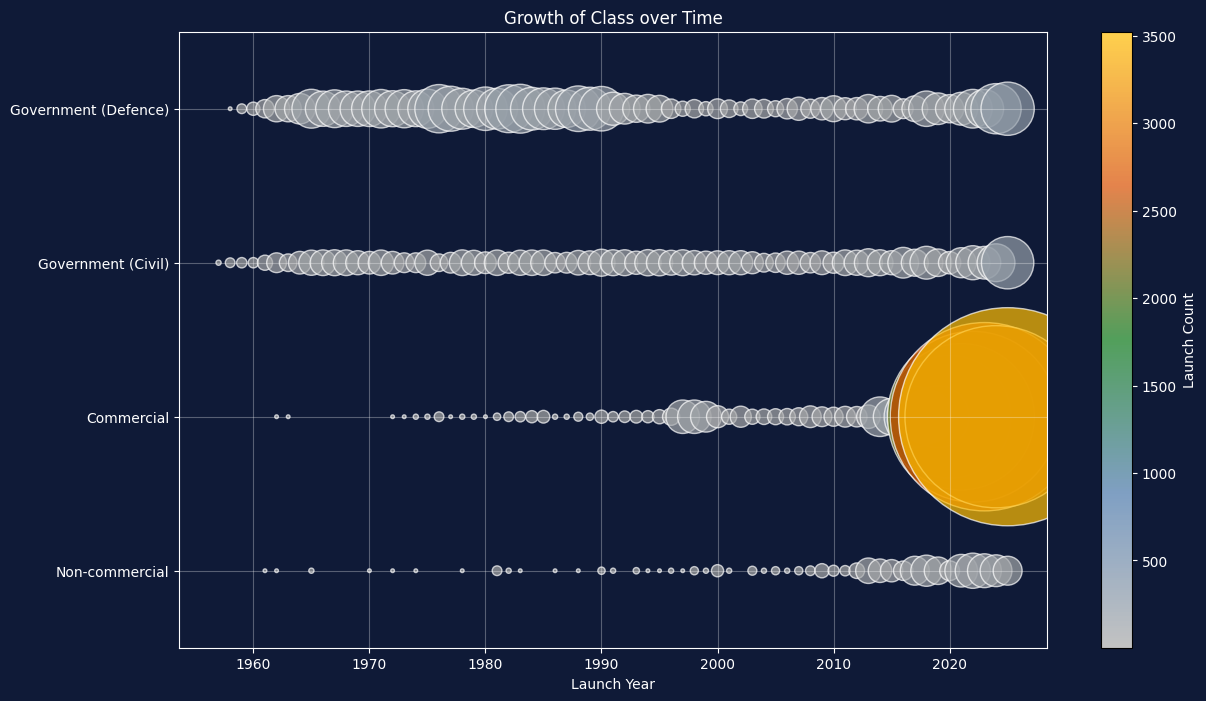

In [65]:
import matplotlib.pyplot as plt
import pandas as pd

# Fix filter (you referenced sdf in the second condition)
filtered = sdf_all_payloads[
    (sdf_all_payloads["Class"] != "Unknown") &
    (sdf_all_payloads["Class"].notna())
]

# Counts
program_counts = (
    filtered.groupby(["Class", "Launch Year"])
    .size()
    .reset_index(name="count")
)

# Top classes (you likely want all 4 classes, not "top 20" classes)
class_order = ["Government (Defence)", "Government (Civil)", "Commercial", "Non-commercial"]

# Keep only rows with desired classes
program_counts = program_counts[program_counts["Class"].isin(class_order)]

# Map classes to y positions
pos = {c: i for i, c in enumerate(class_order)}
program_counts["ypos"] = program_counts["Class"].map(pos)

# Bubble chart
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor(bg)
ax.set_facecolor(bg)

scatter = ax.scatter(
    program_counts["Launch Year"],
    program_counts["ypos"],
    s=program_counts["count"] * 7,
    alpha=0.7,
    c=program_counts["count"],
    cmap=cmap_three,
    edgecolors=linecol
)

# Ticks only for classes present (in order)
present = [c for c in class_order if c in program_counts["Class"].unique()]
ax.set_yticks([pos[c] for c in present])
ax.set_yticklabels(present, color=linecol)

# Optional: put "Government (Defence)" at the top
ax.set_ylim(-0.5, len(class_order) - 0.5)
ax.invert_yaxis()

ax.set_title("Growth of Class over Time", color=linecol)
ax.set_xlabel("Launch Year", color=linecol)
ax.tick_params(colors=linecol)
for spine in ax.spines.values():
    spine.set_color('white')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Launch Count", color=linecol)
cbar.ax.yaxis.set_tick_params(color=linecol)
plt.setp(cbar.ax.get_yticklabels(), color=linecol)

ax.grid(True, color=linecol, alpha=0.3)
plt.show()



In [43]:
#I would like to filter this graph by USA, RU and others.
# There are some N/A fields

def country_group(country):
    if country == "Russia":
        return "Russia"
    elif country == "USA":
        return "USA"
    else:
        return "Others"

#sdf["Country Group"] = sdf["Country"].map(country_group)

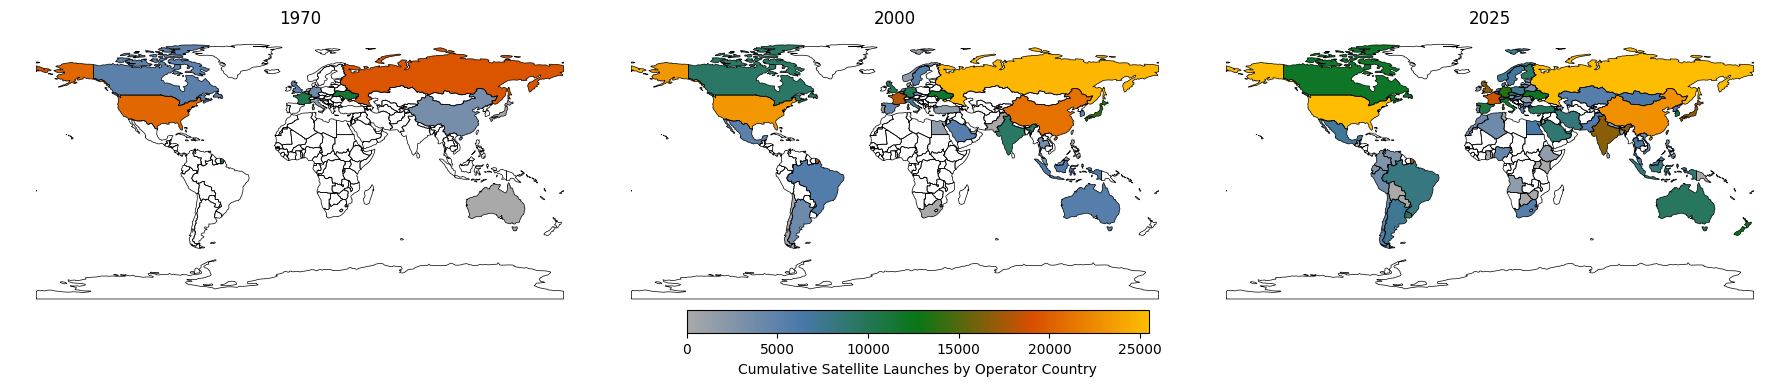

In [66]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as colors



#world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
world = gpd.read_file('ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp')

# Compute global max across all cutoff years
cutoffs = [1970, 2000, 2025]
max_count = 0
country_data = {}

for year in cutoffs:
    df_cut = sdf[sdf['Launch Year'] <= year]
    country_counts = df_cut.groupby('Operator Country Code').size().reset_index(name='Count')
    country_data[year] = country_counts
    max_count = max(max_count, country_counts['Count'].max())

norm = colors.LogNorm(vmin=1, vmax=max_count)  # log scale

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# We'll keep track of the last plot so we can use it for the colorbar
mappable = None

for ax, year in zip(axes, cutoffs):
    # Merge with shapefile
    merged = world.merge(country_data[year], left_on='ADM0_A3', right_on='Operator Country Code', how='left')
    merged['Count'] = merged['Count'].fillna(0)
    
    # Plot boundaries first
    world.boundary.plot(ax=ax, color="black", linewidth=0.5)
    
    # Plot shaded map
    #merged.plot(column='Count', cmap=cmap_two, ax=ax, vmin=0, vmax=max_count, legend=False)
    mappable = merged.plot(column='Count', cmap=cmap_three, ax=ax,
            norm=norm, legend=False)
    
    ax.set_title(f"{year}")
    ax.axis('off')

# Now add a single shared colorbar below all maps
sm = plt.cm.ScalarMappable(cmap=cmap_three, norm=plt.Normalize(vmin=0, vmax=max_count))
sm.set_array([])  # required for colorbar

cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation='horizontal',
                    fraction=0.05, pad=0.05)
cbar.set_label("Cumulative Satellite Launches by Operator Country")

plt.tight_layout(rect=[0, 0.12, 1, 1])  # leave space at bottom
plt.show()


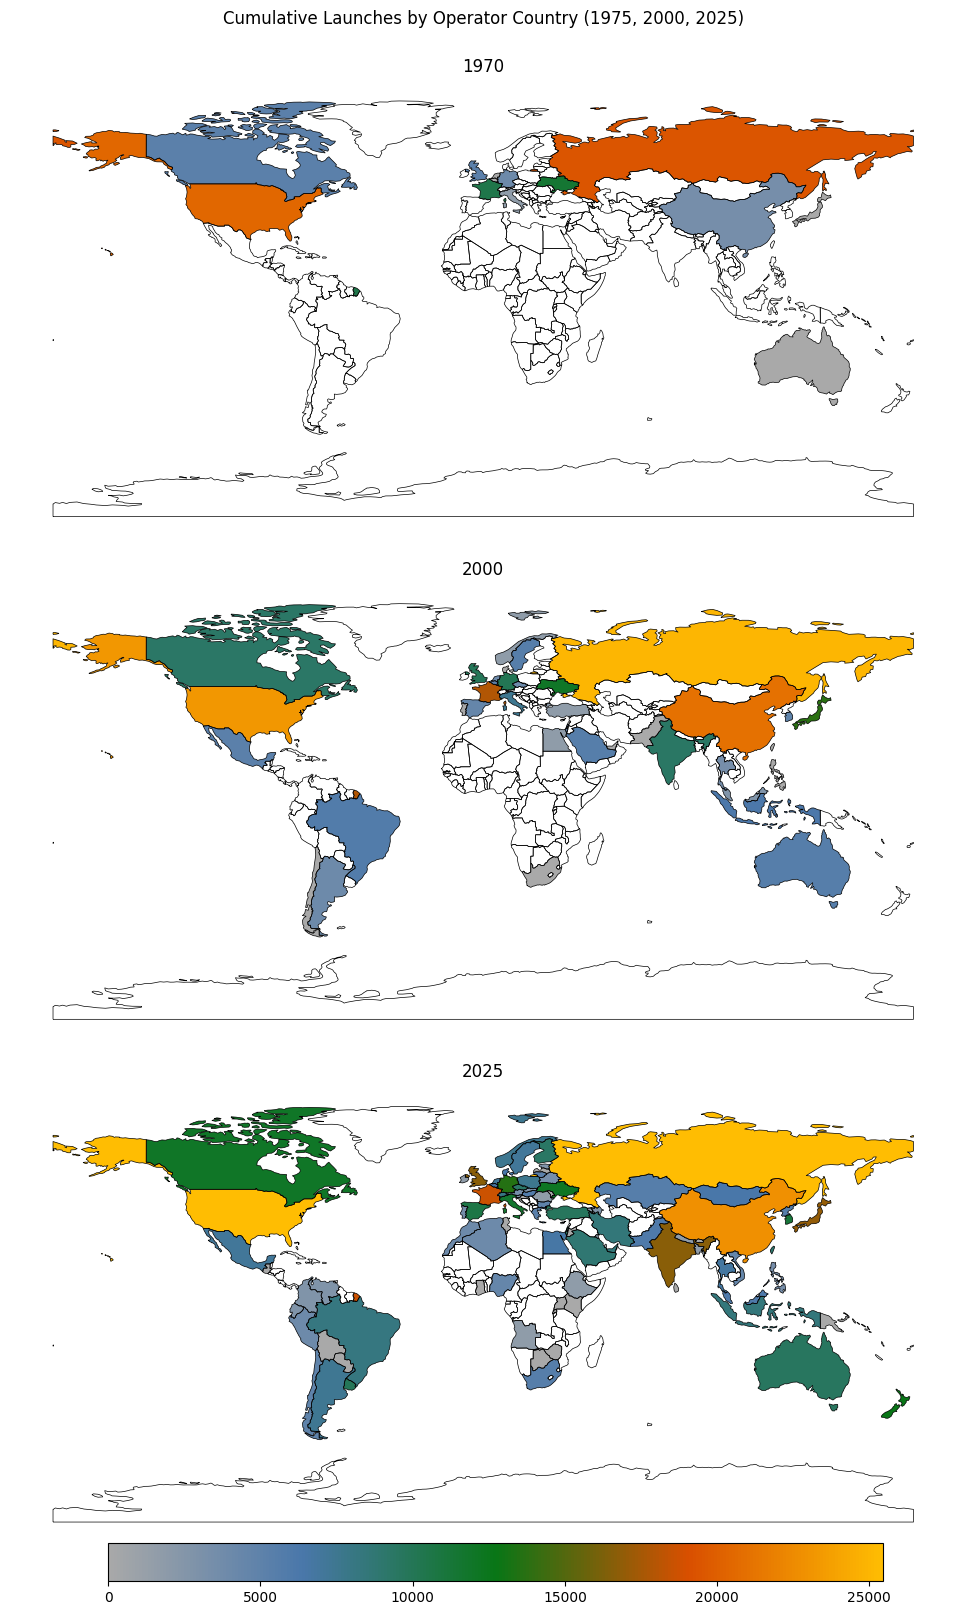

In [67]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as colors



#world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
world = gpd.read_file('ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp')

# Compute global max across all cutoff years
cutoffs = [1970, 2000, 2025]
max_count = 0
country_data = {}

for year in cutoffs:
    df_cut = sdf[sdf['Launch Year'] <= year]
    country_counts = df_cut.groupby('Operator Country Code').size().reset_index(name='Count')
    country_data[year] = country_counts
    max_count = max(max_count, country_counts['Count'].max())

norm = colors.LogNorm(vmin=1, vmax=max_count)  # log scale

# Create vertical subplots
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 18))

# We'll keep track of the last plot so we can use it for the colorbar
mappable = None

for ax, year in zip(axes, cutoffs):
    # Merge with shapefile
    merged = world.merge(country_data[year], left_on='ADM0_A3', right_on='Operator Country Code', how='left')
    merged['Count'] = merged['Count'].fillna(0)
    
    # Plot boundaries first
    world.boundary.plot(ax=ax, color="black", linewidth=0.5)
    
    # Plot shaded map
    #merged.plot(column='Count', cmap=cmap_two, ax=ax, vmin=0, vmax=max_count, legend=False)
    mappable = merged.plot(column='Count', cmap=cmap_three, ax=ax,
            norm=norm, legend=False)
    
    ax.set_title(f"{year}")
    ax.axis('off')

# Now add a single shared colorbar below all maps
sm = plt.cm.ScalarMappable(cmap=cmap_three, norm=plt.Normalize(vmin=0, vmax=max_count))
sm.set_array([])  # required for colorbar

cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation='horizontal',
                    fraction=0.05, pad=0.05)
#cbar.set_label("Cumulative Satellite Launches by Operator Country")

# Add a main title above everything
fig.suptitle("Cumulative Launches by Operator Country (1975, 2000, 2025)", fontsize=12, y=1.00)

plt.tight_layout(rect=[0, 0.14, 1, 1])  # leave space at bottom
plt.show()


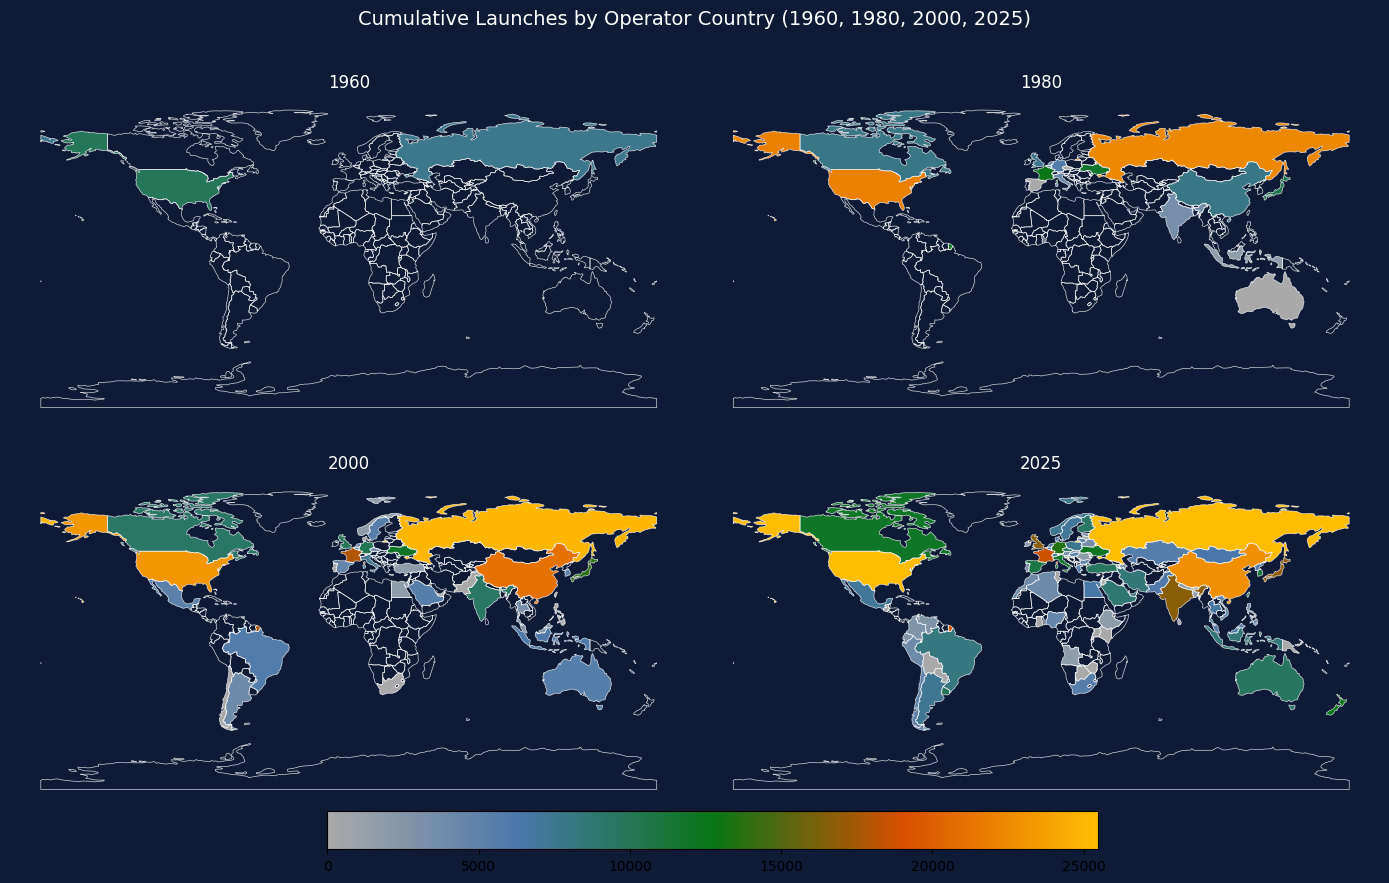

In [77]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# Load shapefile
world = gpd.read_file('ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp')

# Compute global max across all cutoff years
cutoffs = [1960, 1980, 2000, 2025]
max_count = 0
country_data = {}

for year in cutoffs:
    df_cut = sdf[sdf['Launch Year'] <= year]
    country_counts = df_cut.groupby('Operator Country Code').size().reset_index(name='Count')
    country_data[year] = country_counts
    max_count = max(max_count, country_counts['Count'].max())

# Use log scale for shading
norm = colors.LogNorm(vmin=1, vmax=max_count)

# Create 2x2 grid of subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
fig.facecolor = bg
fig.patch.set_facecolor(bg)

# Flatten axes array for easy iteration
axes = axes.ravel()

for ax, year in zip(axes, cutoffs):
    # Merge with shapefile
    merged = world.merge(country_data[year], left_on='ADM0_A3', right_on='Operator Country Code', how='left')
    merged['Count'] = merged['Count'].fillna(0)
    
    # Plot boundaries first
    world.boundary.plot(ax=ax, color="white", linewidth=0.5, alpha=0.8)
    
    # Plot shaded map
    merged.plot(column='Count', cmap=cmap_three, ax=ax,
                norm=norm, legend=False)
    
    ax.set_title(f"{year}", color=linecol)
    ax.axis('off')

# Shared colorbar below all maps
sm = plt.cm.ScalarMappable(cmap=cmap_three, norm=plt.Normalize(vmin=0, vmax=max_count))
sm.set_array([])  # required for colorbar

cbar = fig.colorbar(sm, ax=axes.tolist(), orientation='horizontal',
                    fraction=0.05, pad=0.05)
#cbar.set_label("Cumulative Satellite Launches by Operator Country")

# Add a main title above everything
fig.suptitle("Cumulative Launches by Operator Country (1960, 1980, 2000, 2025)", fontsize=14, y=0.95, color=linecol)

#plt.tight_layout(rect=[0, 0.08, 1, 0.95])  # leave space at bottom for colorbar

plt.tight_layout(rect=[0, 0.14, 1, 1])  # leave space at bottom
plt.show()


Connections between entities

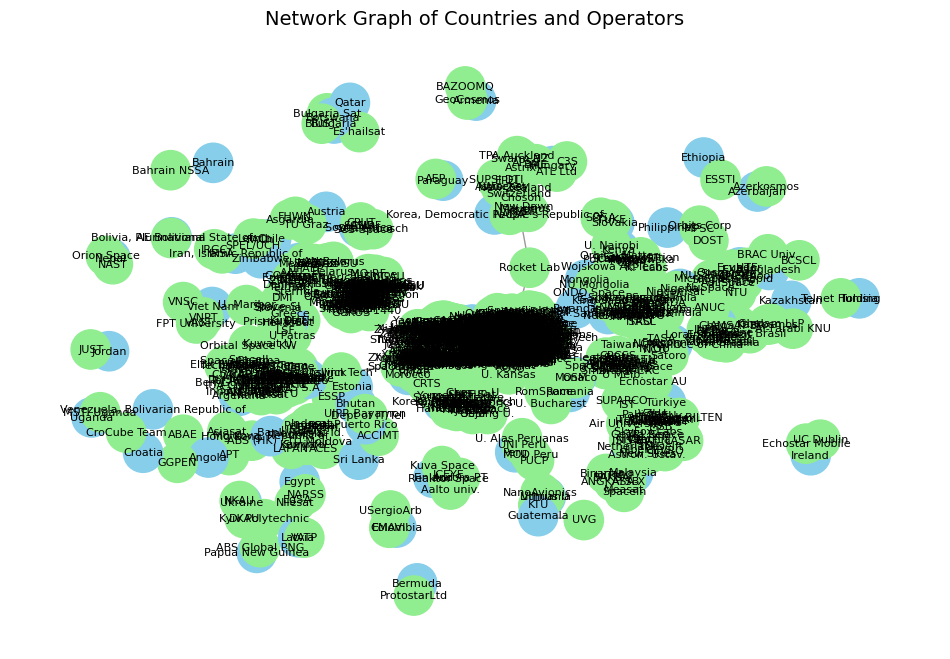

In [47]:
import networkx as nx
import matplotlib.pyplot as plt

# Assume sdf is your dataframe

# Create a graph
G = nx.Graph()

# Add edges between Country and Operator Short Name
for _, row in sdf.iterrows():
    country = row['Country']
    operator = row['Operator Short Name']
    
    # Only add if both are not null
    if pd.notna(country) and pd.notna(operator):
        G.add_node(country, type='country')
        G.add_node(operator, type='operator')
        G.add_edge(country, operator)

# Define node colours based on type
color_map = []
for node in G.nodes(data=True):
    if node[1]['type'] == 'country':
        color_map.append('skyblue')   # Countries
    else:
        color_map.append('lightgreen') # Operators

# Draw the graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.5, seed=42)  # Layout for readability
nx.draw_networkx_nodes(G, pos, node_color=color_map, node_size=800)
nx.draw_networkx_edges(G, pos, alpha=0.4)
nx.draw_networkx_labels(G, pos, font_size=8)

plt.title("Network Graph of Countries and Operators", fontsize=14)
plt.axis('off')
plt.show()


In [48]:
import pandas as pd
import plotly.graph_objects as go

# Example: assume sdf is your dataframe
# Build a frequency matrix of Country vs Operator
matrix = sdf.groupby(['Country', 'Operator Short Name']).size().reset_index(name='count')

# Get unique labels (countries + operators)
countries = matrix['Country'].unique().tolist()
operators = matrix['Operator Short Name'].unique().tolist()
labels = countries + operators

# Build source-target pairs
sources = []
targets = []
values = []

for _, row in matrix.iterrows():
    sources.append(labels.index(row['Country']))
    targets.append(labels.index(row['Operator Short Name']))
    values.append(row['count'])

# Create a Sankey diagram (works like a chord chart)
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels,
        color=["skyblue"]*len(countries) + ["lightgreen"]*len(operators)
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    ))])

fig.update_layout(title_text="Chord-style Chart: Countries ↔ Operators", font_size=10)
fig.show()


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
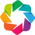

:Chord   [start,end]

In [49]:
import pandas as pd
import holoviews as hv
from holoviews import opts

hv.extension('bokeh')

# Example: build a dataframe of relationships
matrix = sdf.groupby(['Country', 'Operator Short Name']).size().reset_index(name='count')

# Create edges for chord diagram
edges = []
for _, row in matrix.iterrows():
    edges.append((row['Country'], row['Operator Short Name'], row['count']))

# Convert to Holoviews dataset
chord = hv.Chord(edges)

# Style options
chord.opts(
    opts.Chord(
        cmap='Category20',
        edge_color='source',
        node_color='index',
        labels='index',
        node_size=15,
        edge_line_width=hv.dim('count')*0.05,  # scale edge thickness by count
    )
)

# Display in notebook / interactive environment
chord


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
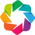

:Chord   [start,end]

In [50]:
import pandas as pd
import holoviews as hv
from holoviews import opts

hv.extension('bokeh')

# Step 1: Count satellites per Country-Operator pair
matrix = sdf.groupby(['Country', 'Operator Short Name']).size().reset_index(name='count')

# Step 2: For each country, keep only the top 5 operators
top_ops = (
    matrix.groupby('Country', group_keys=False)
    .apply(lambda g: g.nlargest(5, 'count'))
)

# Step 3: Build edges for chord diagram
edges = [(row['Country'], row['Operator Short Name'], row['count']) 
         for _, row in top_ops.iterrows()]

# Step 4: Create chord diagram
chord = hv.Chord(edges)

# Step 5: Style options
chord.opts(
    opts.Chord(
        cmap='Category20',
        edge_color='source',
        node_color='index',
        labels='index',
        node_size=15,
        edge_line_width=hv.dim('count')*0.05,  # scale edge thickness by count
    )
)

chord


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
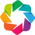

:Chord   [start,end]

In [51]:
import pandas as pd
import holoviews as hv
from holoviews import opts

hv.extension('bokeh')

# Step 1: Count satellites per Country-Operator pair
matrix = sdf.groupby(['Country', 'Operator Short Name']).size().reset_index(name='count')

# Step 2: For each country, keep only the top 5 operators
top_ops = (
    matrix.groupby('Country', group_keys=False)
    .apply(lambda g: g.nlargest(5, 'count'))
)

# Step 3: Find the top 30 countries overall (by total satellites)
top_countries = (
    top_ops.groupby('Country')['count']
    .sum()
    .nlargest(30)
    .index
)

# Step 4: Filter to only those top 30 countries
filtered = top_ops[top_ops['Country'].isin(top_countries)]

# Step 5: Build edges for chord diagram
edges = [(row['Country'], row['Operator Short Name'], row['count']) 
         for _, row in filtered.iterrows()]

# Step 6: Create chord diagram
chord = hv.Chord(edges)

# Step 7: Style options
chord.opts(
    opts.Chord(
        cmap='Category20',
        edge_color='source',
        node_color='index',
        labels='index',
        node_size=15,
        edge_line_width=hv.dim('count')*0.05,
        width=1000,   # make the figure wider
        height=1000,  # make the figure taller
    )
)


chord


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
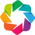

:Chord   [Country,Operator]   (launches)

In [52]:
import pandas as pd
import holoviews as hv
from holoviews import opts

hv.extension('bokeh')

# Step 1: Count launches per Country-Operator pair
launch_counts = (
    sdf.groupby(['Country', 'Operator Short Name'])['Launch Year']
    .count()
    .reset_index(name='launches')
)

# Step 2: For each country, keep only the top 5 operators by launches
top_ops = (
    launch_counts.groupby('Country', group_keys=False)
    .apply(lambda g: g.nlargest(5, 'launches'))
)

# Step 3: Find the top 30 countries overall (by total launches)
top_countries = (
    top_ops.groupby('Country')['launches']
    .sum()
    .nlargest(30)
    .index
)

# Step 4: Filter to only those top 30 countries
filtered = top_ops[top_ops['Country'].isin(top_countries)]

# Step 5: Rename column so Holoviews can use it cleanly
edges_df = filtered.rename(columns={'Operator Short Name': 'Operator'})

# Step 6: Create hv.Dataset with correct dimension names
dataset = hv.Dataset(edges_df, kdims=['Country', 'Operator'], vdims=['launches'])

# Step 7: Build chord diagram
chord = hv.Chord(dataset)

# Step 8: Style options
chord.opts(
    opts.Chord(
        cmap='Category20',
        edge_color='Country',             # color edges by country
        node_color='index',               # color nodes by their label
        labels='index',
        node_size=15,
        edge_line_width=hv.dim('launches')*0.05,  # thickness by launches
        width=1200,
        height=1200
    )
)

chord


On world map with weighted lines for connectivity


launch sites - map, blobs sized through frequency of use.

## Apogee and Perigee

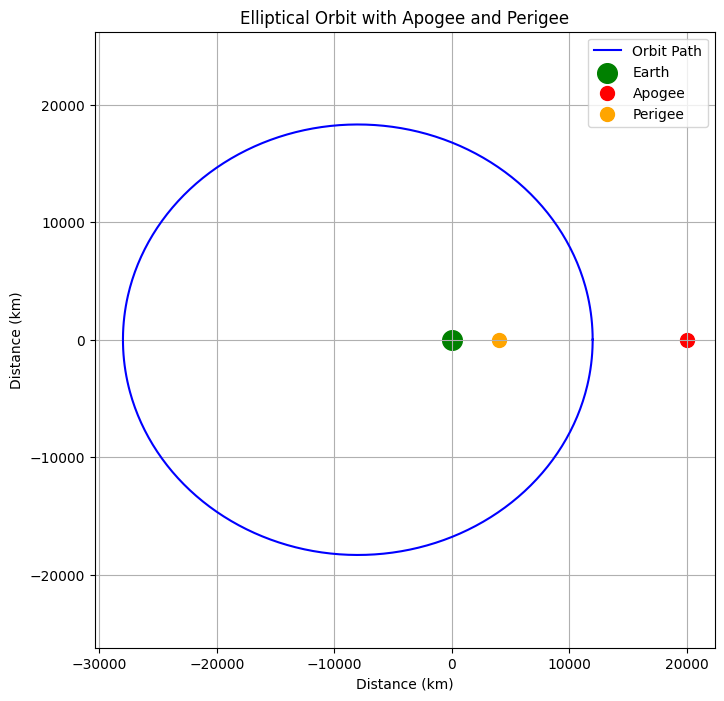

In [53]:
import matplotlib.pyplot as plt
import numpy as np

# Example orbital parameters (semi-major axis and eccentricity)
semi_major_axis = 20000   # km
eccentricity = 0.4        # 0 = circle, closer to 1 = very stretched

# Calculate semi-minor axis
semi_minor_axis = semi_major_axis * np.sqrt(1 - eccentricity**2)

# Parametric equation for ellipse
theta = np.linspace(0, 2*np.pi, 500)
x = semi_major_axis * np.cos(theta) - semi_major_axis * eccentricity  # shift Earth to one focus
y = semi_minor_axis * np.sin(theta)

# Apogee (farthest point) and Perigee (closest point)
apogee_x = semi_major_axis * (1 + eccentricity) - semi_major_axis * eccentricity
apogee_y = 0
perigee_x = semi_major_axis * (1 - eccentricity) - semi_major_axis * eccentricity
perigee_y = 0

# Plot
plt.figure(figsize=(8,8))
plt.plot(x, y, label='Orbit Path', color='blue')
plt.scatter(0, 0, color='green', s=200, label='Earth')  # Earth at focus
plt.scatter(apogee_x, apogee_y, color='red', s=100, label='Apogee')
plt.scatter(perigee_x, perigee_y, color='orange', s=100, label='Perigee')

# Labels and styling
plt.title('Elliptical Orbit with Apogee and Perigee')
plt.xlabel('Distance (km)')
plt.ylabel('Distance (km)')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()


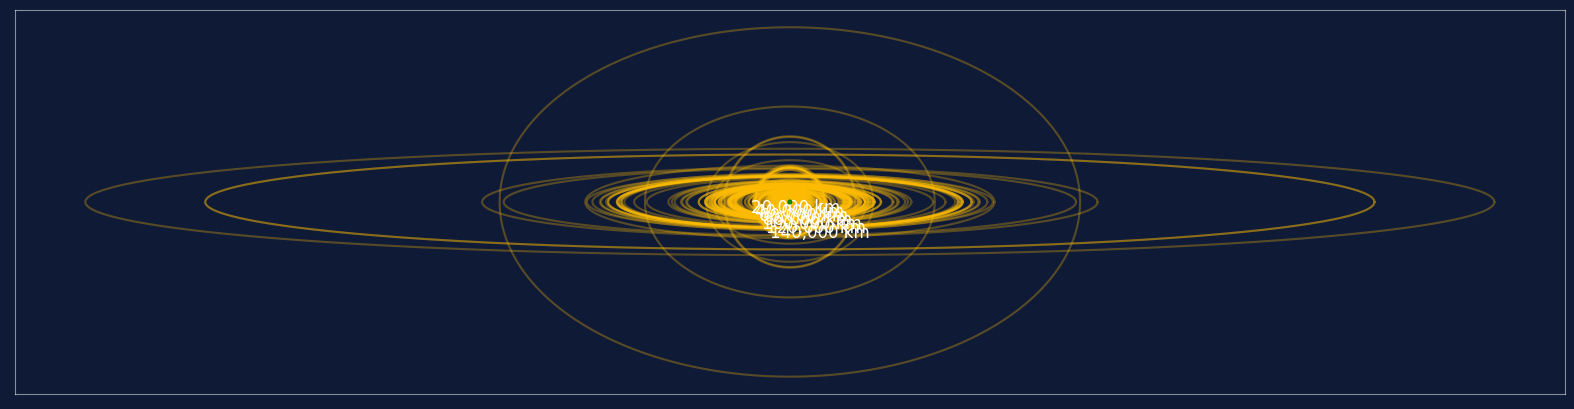

In [54]:
# Filter dataframe for payloads still in orbit
payloads = sdf[(sdf['Type'] == 'Payload') & (sdf['In Orbit'] == True)].copy()

# Ensure numeric values
payloads['Apogee'] = pd.to_numeric(payloads['Apogee'], errors='coerce')
payloads['Perigee'] = pd.to_numeric(payloads['Perigee'], errors='coerce')

# Drop rows with missing values
payloads = payloads.dropna(subset=['Apogee', 'Perigee'])

# Convert altitudes to orbital radii (distance from Earth's center)
earth_radius = 6371  # km
payloads['Apogee']  = payloads['Apogee']  + earth_radius
payloads['Perigee'] = payloads['Perigee'] + earth_radius

# Plot setup with background and white styling
fig, ax = plt.subplots(figsize=(20,20), facecolor=bg)
ax.set_facecolor(bg)

theta = np.linspace(0, 2*np.pi, 500)

for _, row in payloads.iterrows():
    ra = row['Apogee']   # apogee radius (km from center)
    rp = row['Perigee']  # perigee radius (km from center)

    # Skip invalid radii
    if ra <= 0 or rp <= 0:
        continue

    # Orbital elements
    a = (ra + rp) / 2.0                   # semi-major axis
    e = (ra - rp) / (ra + rp)             # eccentricity
    b = np.sqrt(ra * rp)                  # semi-minor axis (since b^2 = a^2(1-e^2) = ra*rp)

    # Centered ellipse (Earth at the origin, no skew)
    x = a * np.cos(theta)
    y = b * np.sin(theta)

    # Optional: random rotation to avoid all ellipses aligned the same way
    # omega = np.random.uniform(0, 2*np.pi)
    # xr = x * np.cos(omega) - y * np.sin(omega)
    # yr = x * np.sin(omega) + y * np.cos(omega)
    # ax.plot(xr, yr, alpha=0.3, color=linecol)

    if graph_media == 'paper':
        ax.plot(x, y, alpha=0.3, color=graph_palette['foreground']['taupe'])
    else:
        ax.plot(x, y, alpha=0.3, color=graph_palette['foreground']['gold'])


# Define altitude ticks (every 500 km up to max_apogee_altitude)
altitude_ticks = np.arange(0, 150000, 10000)   # [0, 500, 1000]
radius_ticks = earth_radius + altitude_ticks                # convert to orbital radii

# Draw faint concentric rings at each tick radius
#for r in radius_ticks:
#    ring = plt.Circle(
#        (0, 0), r,
#        color=graph_palette['foreground']['steelBlue'],
#        fill=False,
#        alpha=0.2,
#        linestyle='--'
#    )
#    ax.add_artist(ring)

# Add labels every second ring (i.e. skip odd indices)
for i, (alt, r) in enumerate(zip(altitude_ticks, radius_ticks)):
    if alt == 0:
        continue  # skip the 0 km ring
    if i % 2 == 0:  # every second ring (1000 km, 2000 km, ...)
        angle = np.deg2rad(315)  # 60 degrees in radians
        x = r * np.cos(angle)
        y = r * np.sin(angle)
        ax.text(
            x, y,
            f"{alt:,} km",
            color=linecol,
            ha='center',
            va='center',
            rotation=0,   # tilt text itself
            fontsize=12
        )


# Draw Earth as a filled circle at the center
earth_circle = plt.Circle((0, 0), earth_radius, color='green', alpha=0.9, zorder=10)
ax.add_artist(earth_circle)

# White text and ticks
ax.tick_params(axis='x', colors=bg)
ax.tick_params(axis='y', colors=bg)
ax.set_xticklabels([])   # hides the labels but keeps tick marks
ax.set_yticklabels([])   # hides the labels but keeps tick marks

# Modify the box around the plot
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color(linecol)
    spine.set_alpha(0.5)

# No legend
ax.legend().remove()

ax.set_aspect('equal')


if graph_media == 'paper':
    ax.plot(x, y, alpha=0.3, color=graph_palette['foreground']['lavender'])
else:
    ax.plot(x, y, alpha=0.3, color=graph_palette['foreground']['steelBlue'])

plt.show()


KeyError: 'greyOlive'

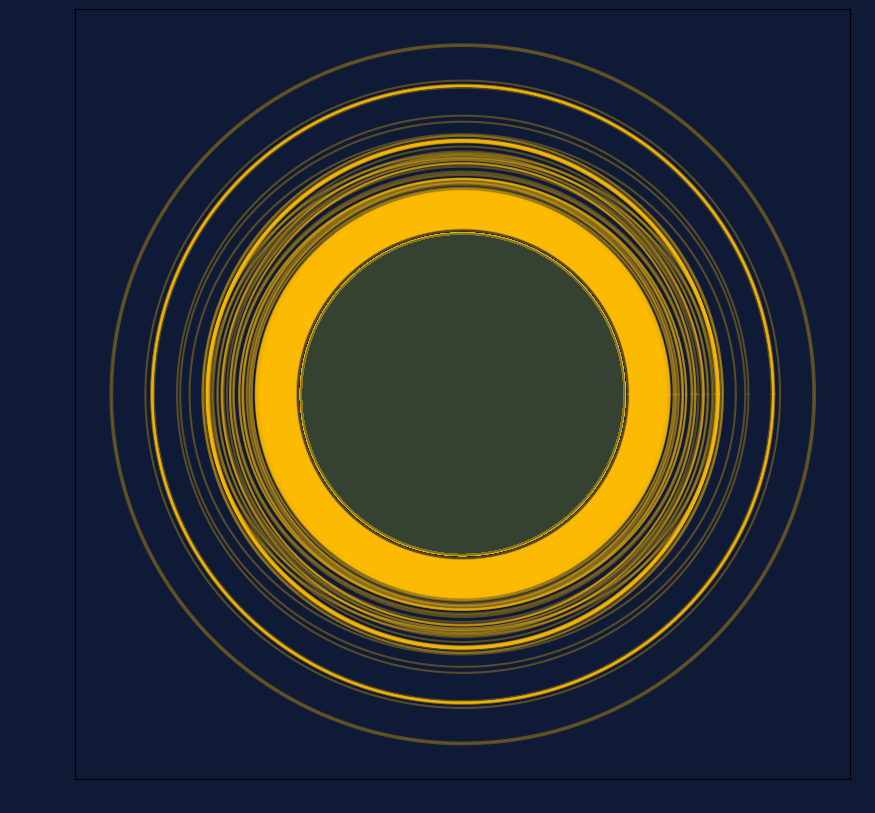

In [55]:
# Define maximum apogee altitude (km above Earth's surface)
max_apogee_altitude = 7500

# Convert to orbital radius (distance from Earth's center)
max_apogee_radius = earth_radius + max_apogee_altitude

# Filter dataframe for payloads still in orbit
payloads = sdf[(sdf['Type'] == 'Payload') & (sdf['In Orbit'] == True)].copy()


# Ensure numeric values
payloads['Apogee'] = pd.to_numeric(payloads['Apogee'], errors='coerce')
payloads['Perigee'] = pd.to_numeric(payloads['Perigee'], errors='coerce')

# Drop rows with missing values
payloads = payloads.dropna(subset=['Apogee', 'Perigee'])

# Apply prefilter
payloads = payloads[payloads['Apogee'] <= max_apogee_altitude]

# Convert altitudes to orbital radii (distance from Earth's center)
earth_radius = 6371  # km
payloads['Apogee']  = payloads['Apogee']  + earth_radius
payloads['Perigee'] = payloads['Perigee'] + earth_radius

# Plot setup with background and white styling
fig, ax = plt.subplots(figsize=(10,10), facecolor=bg)
ax.set_facecolor(bg)

max_extent = 0
theta = np.linspace(0, 2*np.pi, 500)

for _, row in payloads.iterrows():
    ra = row['Apogee']   # apogee radius (km from center)
    rp = row['Perigee']  # perigee radius (km from center)

    # Skip invalid radii
    if ra <= 0 or rp <= 0:
        continue

    # Orbital elements
    a = (ra + rp) / 2.0                   # semi-major axis
    e = (ra - rp) / (ra + rp)             # eccentricity
    b = np.sqrt(ra * rp)                  # semi-minor axis (since b^2 = a^2(1-e^2) = ra*rp)

    # Centered ellipse (Earth at the origin, no skew)
    x = a * np.cos(theta)
    y = b * np.sin(theta)

    # maximum radius of this ellipse
    orbit_max = max(a, b)
    if orbit_max > max_extent:
        max_extent = orbit_max

    if graph_media == 'paper':
        ax.plot(x, y, alpha=0.3, color=graph_palette['foreground']['duskBlue'])
    else:
        ax.plot(x, y, alpha=0.3, color=graph_palette['foreground']['gold'])


# Draw Earth as a filled circle at the center
earth_circle = plt.Circle((0, 0), earth_radius, color='#4F5D2F', alpha=0.6, zorder=10)
ax.add_artist(earth_circle)

# White text and ticks
#ax.set_title('Orbits of Payloads Currently in Orbit', color=linecol)
#ax.set_xlabel('Distance (km)', color=linecol)
#ax.set_ylabel('Distance (km)', color=linecol)
ax.tick_params(axis='x', colors=bg)
ax.tick_params(axis='y', colors=bg)
#ax.set_xticklabels([])   # hides the labels but keeps tick marks
#ax.set_yticklabels([])   # hides the labels but keeps tick marks


# Define altitude ticks (every 500 km up to max_apogee_altitude)
altitude_ticks = np.arange(0, max_apogee_altitude+1001, 500)   # [0, 500, 1000]
radius_ticks = earth_radius + altitude_ticks                # convert to orbital radii

# Draw faint concentric rings at each tick radius
for r in radius_ticks:
    ring = plt.Circle(
        (0, 0), r,
        color=graph_palette['foreground']['greyOlive'],
        fill=False,
        alpha=0.2,
        linestyle='--'
    )
    ax.add_artist(ring)

# Add labels every second ring (i.e. skip odd indices)
#for i, (alt, r) in enumerate(zip(altitude_ticks, radius_ticks)):
#    if alt == 0:
#        continue  # skip the 0 km ring
#    if i % 5 == 0:  # every second ring (1000 km, 2000 km, ...)
#        angle = np.deg2rad(45)  # 60 degrees in radians
#        x = r * np.cos(angle)
#        y = r * np.sin(angle)
#        ax.text(
#            x, y,
#            f"{alt:,} km",
#            color=linecol,
#            ha='center',
#            va='center',
#            rotation=0,   # tilt text itself
#            fontsize=20
#        )

# Apply ticks to both axes
#ax.set_xticks(radius_ticks)
#ax.set_yticks(radius_ticks)

# Formatter: show altitude instead of radius
#def radius_to_altitude(x, pos):
#    return f"{int(x - earth_radius)} km"

#ax.xaxis.set_major_formatter(mticker.FuncFormatter(radius_to_altitude))
#ax.yaxis.set_major_formatter(mticker.FuncFormatter(radius_to_altitude))

# No legend
ax.legend().remove()

# Modify the box around the plot
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color(linecol)
    spine.set_alpha(0.5)

ax.set_aspect('equal')
#ax.grid(True, color=graph_palette['foreground']['steelBlue'], alpha=0.5)
ax.yaxis.grid(False)
ax.xaxis.grid(False)

# Draw arrow from Earth’s surface to edge of orbit cloud
ax.annotate(
    '',
    xy=(max_extent, 0),       # tip at orbit edge
    xytext=(earth_radius, 0), # tail at Earth’s surface
    arrowprops=dict(
        facecolor=linecol,
        edgecolor=linecol,
        shrink=0,
        width=2,
        headwidth=10,
        alpha=0.8
    )
)

# Label the distance
ax.text(
    (earth_radius + max_extent)/2, 220,
    f'{int(round(max_extent - earth_radius,-2)):,} km',
    color=linecol,
    ha='center',
    fontsize=20
)

plt.show()


In [ ]:
# Define maximum apogee altitude (km above Earth's surface)
max_apogee_altitude = 2000 

# Convert to orbital radius (distance from Earth's center)
max_apogee_radius = earth_radius + max_apogee_altitude

# Filter dataframe for payloads still in orbit
payloads = sdf[(sdf['Type'] == 'Payload') & (sdf['In Orbit'] == True)].copy()


# Ensure numeric values
payloads['Apogee'] = pd.to_numeric(payloads['Apogee'], errors='coerce')
payloads['Perigee'] = pd.to_numeric(payloads['Perigee'], errors='coerce')

# Drop rows with missing values
payloads = payloads.dropna(subset=['Apogee', 'Perigee', 'Class'])

# Apply prefilter
payloads = payloads[payloads['Apogee'] <= max_apogee_altitude]

# Convert altitudes to orbital radii (distance from Earth's center)
earth_radius = 6371  # km
payloads['Apogee']  = payloads['Apogee']  + earth_radius
payloads['Perigee'] = payloads['Perigee'] + earth_radius

# Plot setup with background and white styling
fig, ax = plt.subplots(figsize=(10,10), facecolor=bg)
ax.set_facecolor(bg)

max_extent = 0
# Get the unique classes in your payloads dataframe
classes = payloads['Class'].unique()

# Build a mapping from class → colour
class_colour_map = {cls: foreground_colours[i % len(foreground_colours)]
                    for i, cls in enumerate(classes)}

theta = np.linspace(0, 2*np.pi, 500)

for _, row in payloads.iterrows():
    ra = row['Apogee']   # apogee radius (km from center)
    rp = row['Perigee']  # perigee radius (km from center)

    # Skip invalid radii
    if ra <= 0 or rp <= 0:
        continue

    # Orbital elements
    a = (ra + rp) / 2.0                   # semi-major axis
    e = (ra - rp) / (ra + rp)             # eccentricity
    b = np.sqrt(ra * rp)                  # semi-minor axis (since b^2 = a^2(1-e^2) = ra*rp)

    # Centered ellipse (Earth at the origin, no skew)
    x = a * np.cos(theta)
    y = b * np.sin(theta)

    # maximum radius of this ellipse
    orbit_max = max(a, b)
    if orbit_max > max_extent:
        max_extent = orbit_max

    # Pick colour based on the orbit's class
    orbit_class = row['Class']
    colour = class_colour_map.get(orbit_class, linecol)  # fallback to white

    ax.plot(x, y, alpha=0.4, color=colour, label=orbit_class)

# Optional: add a legend showing which colour corresponds to which class
handles, labels = ax.get_legend_handles_labels()
by_class = dict(zip(labels, handles))
ax.legend(by_class.values(), by_class.keys(), labelcolor=linecol, fontsize=10, loc="upper right")


# Draw Earth as a filled circle at the center
earth_circle = plt.Circle((0, 0), earth_radius, color='green', alpha=0.6, zorder=10)
ax.add_artist(earth_circle)

# White text and ticks
#ax.set_title('Orbits of Payloads Currently in Orbit', color=linecol)
#ax.set_xlabel('Distance (km)', color=linecol)
#ax.set_ylabel('Distance (km)', color=linecol)
ax.tick_params(axis='x', colors=bg)
ax.tick_params(axis='y', colors=bg)
#ax.set_xticklabels([])   # hides the labels but keeps tick marks
#ax.set_yticklabels([])   # hides the labels but keeps tick marks

# Define altitude ticks (every 500 km up to max_apogee_altitude)
altitude_ticks = np.arange(0, max_apogee_altitude+1001, 500)   # [0, 500, 1000]
radius_ticks = earth_radius + altitude_ticks                # convert to orbital radii

# Draw faint concentric rings at each tick radius
for r in radius_ticks:
    ring = plt.Circle(
        (0, 0), r,
        color=graph_palette['foreground']['steelBlue'],
        fill=False,
        alpha=0.2,
        linestyle='--'
    )
    ax.add_artist(ring)

# Add labels every second ring (i.e. skip odd indices)
for i, (alt, r) in enumerate(zip(altitude_ticks, radius_ticks)):
    if alt == 0:
        continue  # skip the 0 km ring
    if i % 2 == 0:  # every second ring (1000 km, 2000 km, ...)
        angle = np.deg2rad(300)  # 60 degrees in radians
        x = r * np.cos(angle)
        y = r * np.sin(angle)
        ax.text(
            x, y,
            f"{alt} km",
            color=linecol,
            ha='center',
            va='center',
            rotation=0,   # tilt text itself
            fontsize=10
        )

# Apply ticks to both axes
#ax.set_xticks(radius_ticks)
#ax.set_yticks(radius_ticks)

# Formatter: show altitude instead of radius
#def radius_to_altitude(x, pos):
#    return f"{int(x - earth_radius)} km"

#ax.xaxis.set_major_formatter(mticker.FuncFormatter(radius_to_altitude))
#ax.yaxis.set_major_formatter(mticker.FuncFormatter(radius_to_altitude))

# No legend
#ax.legend().remove()


# Modify the box around the plot
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color(linecol)
    spine.set_alpha(0.5)

ax.set_aspect('equal')
#ax.grid(True, color=graph_palette['foreground']['steelBlue'], alpha=0.5)
ax.yaxis.grid(False)
ax.xaxis.grid(False)

# Draw arrow from Earth’s surface to edge of orbit cloud
ax.annotate(
    '',
    xy=(max_extent, 0),       # tip at orbit edge
    xytext=(earth_radius, 0), # tail at Earth’s surface
    arrowprops=dict(
        facecolor=linecol,
        edgecolor=linecol,
        shrink=0,
        width=2,
        headwidth=10,
        alpha=0.8
    )
)

# Label the distance
ax.text(
    (earth_radius + max_extent)/2, 200,
    f'{int(round(max_extent - earth_radius,-2))} km',
    color=linecol,
    ha='center'
)

plt.show()


In [ ]:
# After building your payloads dataframe and converting to orbital radii

theta = np.linspace(0, 2*np.pi, 500)
max_extent = 0

for _, row in payloads.iterrows():
    ra = row['Apogee']
    rp = row['Perigee']
    if ra <= 0 or rp <= 0:
        continue

    a = (ra + rp) / 2.0
    b = np.sqrt(ra * rp)

    # Centered ellipse
    x = a * np.cos(theta)
    y = b * np.sin(theta)
    ax.plot(x, y, alpha=0.3, color=graph_palette['foreground']['gold'])

    # Track the furthest distance reached by this orbit
    orbit_extent = max(np.max(np.abs(x)), np.max(np.abs(y)))
    max_extent = max(max_extent, orbit_extent)

# Draw Earth
earth_circle = plt.Circle((0, 0), earth_radius, color='green', alpha=0.6, zorder=10)
ax.add_artist(earth_circle)

# Now set axis limits based on the maximum extent found
ax.set_xlim(-max_extent, max_extent)
ax.set_ylim(-max_extent, max_extent)


In [ ]:
years = sorted(payloads['Launch Year'].unique())
from matplotlib.animation import FuncAnimation
def update(year):
    ax.clear()
    ax.set_facecolor(bg)
    ax.set_aspect('equal')
    ax.grid(True, color=linecol, alpha=0.2)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(axis='x', colors=linecol)
    ax.tick_params(axis='y', colors=linecol)
    ax.set_title(f'Orbits of Payloads in {year}', color=linecol)
    ax.set_xlabel('Distance (km)', color=linecol)

    # Filter payloads for this year
    subset = payloads[payloads['Launch Year'] == year]

    theta = np.linspace(0, 2*np.pi, 500)
    for _, row in subset.iterrows():
        ra = row['Apogee']
        rp = row['Perigee']
        if ra <= 0 or rp <= 0:
            continue
        a = (ra + rp) / 2.0
        e = (ra - rp) / (ra + rp)
        b = np.sqrt(ra * rp)
        x = a * np.cos(theta)
        y = b * np.sin(theta)
        ax.plot(x, y, alpha=0.3, color=graph_palette['foreground']['gold'])

    # Earth circle
    earth_circle = plt.Circle((0, 0), earth_radius, color='green', alpha=0.6, zorder=10)
    ax.add_artist(earth_circle)

fig, ax = plt.subplots(figsize=(10,10), facecolor=bg)

ani = FuncAnimation(fig, update, frames=years, repeat=False)
# --- Embed inline in Jupyter ---
HTML(ani.to_jshtml())
#plt.show()


In [ ]:
HTML(ani.to_jshtml())

Interensting way to look at it....

In [ ]:

# Filter dataframe for payloads still in orbit
payloads = sdf[(sdf['Type'] == 'Payload') & (sdf['In Orbit'] == True)].copy()

# Ensure numeric values
payloads['Apogee'] = pd.to_numeric(payloads['Apogee'], errors='coerce')
payloads['Launch Decade'] = pd.to_numeric(payloads['Launch Decade'], errors='coerce').astype(int)
payloads = payloads.dropna(subset=['Apogee','Launch Decade'])

# Remove negative apogees
payloads = payloads[payloads['Apogee'] >= 0]

# Bucket apogee into 500 km ranges
bin_width = 250
payloads['Apogee_bin'] = (payloads['Apogee'] // bin_width) * bin_width

# Group by decade and apogee bin
grouped = payloads.groupby(['Launch Decade','Apogee_bin']).size().reset_index(name='count')

# Plot bubble chart
fig, ax = plt.subplots(figsize=(12,8))
fig.patch.set_facecolor(bg)        # background color
ax.set_facecolor(bg)

scatter = ax.scatter(
    grouped['Launch Decade'] * 20,
    grouped['Apogee_bin'],
    s=grouped['count']*10,   # scale bubble size
    c=grouped['count'],
    cmap=cmap_one,
    alpha=0.5,
    edgecolors=linecol
)

# Get unique scaled positions and original labels
unique_decades = sorted(grouped['Launch Decade'].unique())
xticks_scaled = [d * 20 for d in unique_decades]

ax.set_xticks(xticks_scaled)
ax.set_xticklabels(unique_decades, color=linecol)

# White text and lines
ax.set_title('Payload Apogee Distribution by Decade (' + str(bin_width) + 'km bins)', color=linecol)
ax.set_xlabel('Launch Decade', color=linecol)
ax.set_ylabel('Apogee Altitude (km)', color=linecol)
ax.tick_params(colors=linecol)
for spine in ax.spines.values():
    spine.set_color(linecol)



# Colorbar with white text
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Payload Count', color=linecol)
cbar.ax.yaxis.set_tick_params(color=linecol)
plt.setp(cbar.ax.get_yticklabels(), color=linecol)

ax.grid(True, color=linecol, alpha=0.3)
plt.show()  


In [ ]:
import matplotlib.ticker as mticker

# Group as you already do
grouped = payloads.groupby(['Launch Decade','Apogee_bin']).size().reset_index(name='count')

# Build a categorical → numeric mapping with spacing
decades = sorted(grouped['Launch Decade'].unique())
decade_positions = {dec: i*2 for i, dec in enumerate(decades)}  # 0,2,4,...

# Map to spaced x positions
grouped['xpos'] = grouped['Launch Decade'].map(decade_positions)

# Create figure and axes
fig, ax = plt.subplots(figsize=(12,8))
fig.patch.set_facecolor(bg)
ax.set_facecolor(bg)

# Scatter using xpos
scatter = ax.scatter(
    grouped['xpos'],
    grouped['Apogee_bin'],
    s=grouped['count'] * 10,
    c=grouped['count'],
    cmap=cmap_one,
    alpha=0.5,
    edgecolors=linecol
)

# Set ticks at those positions
ax.set_xticks(list(decade_positions.values()))

# Formatter: turn positions back into "1950s", "1960s", …
def decade_formatter(x, pos):
    for dec, xpos in decade_positions.items():
        if xpos == x:
            return f"{dec}s"
    return ""

ax.xaxis.set_major_formatter(mticker.FuncFormatter(decade_formatter))

# Optional: add padding so bubbles at the edges don’t get clipped
ax.set_xlim(min(decade_positions.values()) - 1,
            max(decade_positions.values()) + 1)

# Format y-axis with commas
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, pos: f"{int(y):,}"))

# Styling
ax.set_title(f'Payload Apogee Distribution by Decade ({bin_width} km bins)', color=linecol)
ax.set_xlabel('Launch Decade', color=linecol)
ax.set_ylabel('Apogee Altitude (km)', color=linecol)
ax.tick_params(colors=linecol)
for spine in ax.spines.values():
    spine.set_color(linecol)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Payload Count', color=linecol)
cbar.ax.yaxis.set_tick_params(color=linecol)
plt.setp(cbar.ax.get_yticklabels(), color=linecol)

ax.xaxis.grid(True, color=linecol, alpha=0.15)
ax.yaxis.grid(False)

plt.show()


In [ ]:
sdf_in_orbit[sdf_in_orbit['Apogee'] > 40000]